<a href="https://colab.research.google.com/github/vn322/Wrestling/blob/main/SlepcVik.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Установка необходимых библиотек
!pip install pingouin openpyxl plotly scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.8/204.8 kB 4.9 MB/s eta 0:00:00


Загрузка данных...


Saving SlepcVik.xlsx to SlepcVik (2).xlsx
Названия столбцов для проверки:
До эксперимента: ['Groupe', 'Kesa_Gatame_efficient', 'Ogoshi_30с', 'Ogoshi_60с', 'Ogoshi_90с', 'Ogoshi_120с', 'Hollds_30с', 'Hollds_60с', 'Hollds_90с', 'Hollds_120с', 'throw_var', 'hold_var', 'Ippon_efficient']
После эксперимента: ['Groupe', 'Kesa_Gatame_efficient', 'Ogoshi_30с', 'Ogoshi_60с', 'Ogoshi_90с', 'Ogoshi_120с', 'Hollds_30с', 'Hollds_60с', 'Hollds_90с', 'Hollds_120с', 'throw_var', 'hold_var', 'Ippon_efficient']

РАСШИРЕННЫЙ СТАТИСТИЧЕСКИЙ АНАЛИЗ ДАННЫХ ДЗЮДОИСТОВ

1. ОПИСАТЕЛЬНАЯ СТАТИСТИКА

ДО ЭКСПЕРИМЕНТА:
Экспериментальная группа (Groupe=1): n=10
Контрольная группа (Groupe=0): n=10
       Kesa_Gatame_efficient                  Ippon_efficient               \
                        mean    std  min  max            mean    std   min   
Groupe                                                                       
0                       0.41  0.179  0.1  0.6           0.413  0.248  0.00   
1           

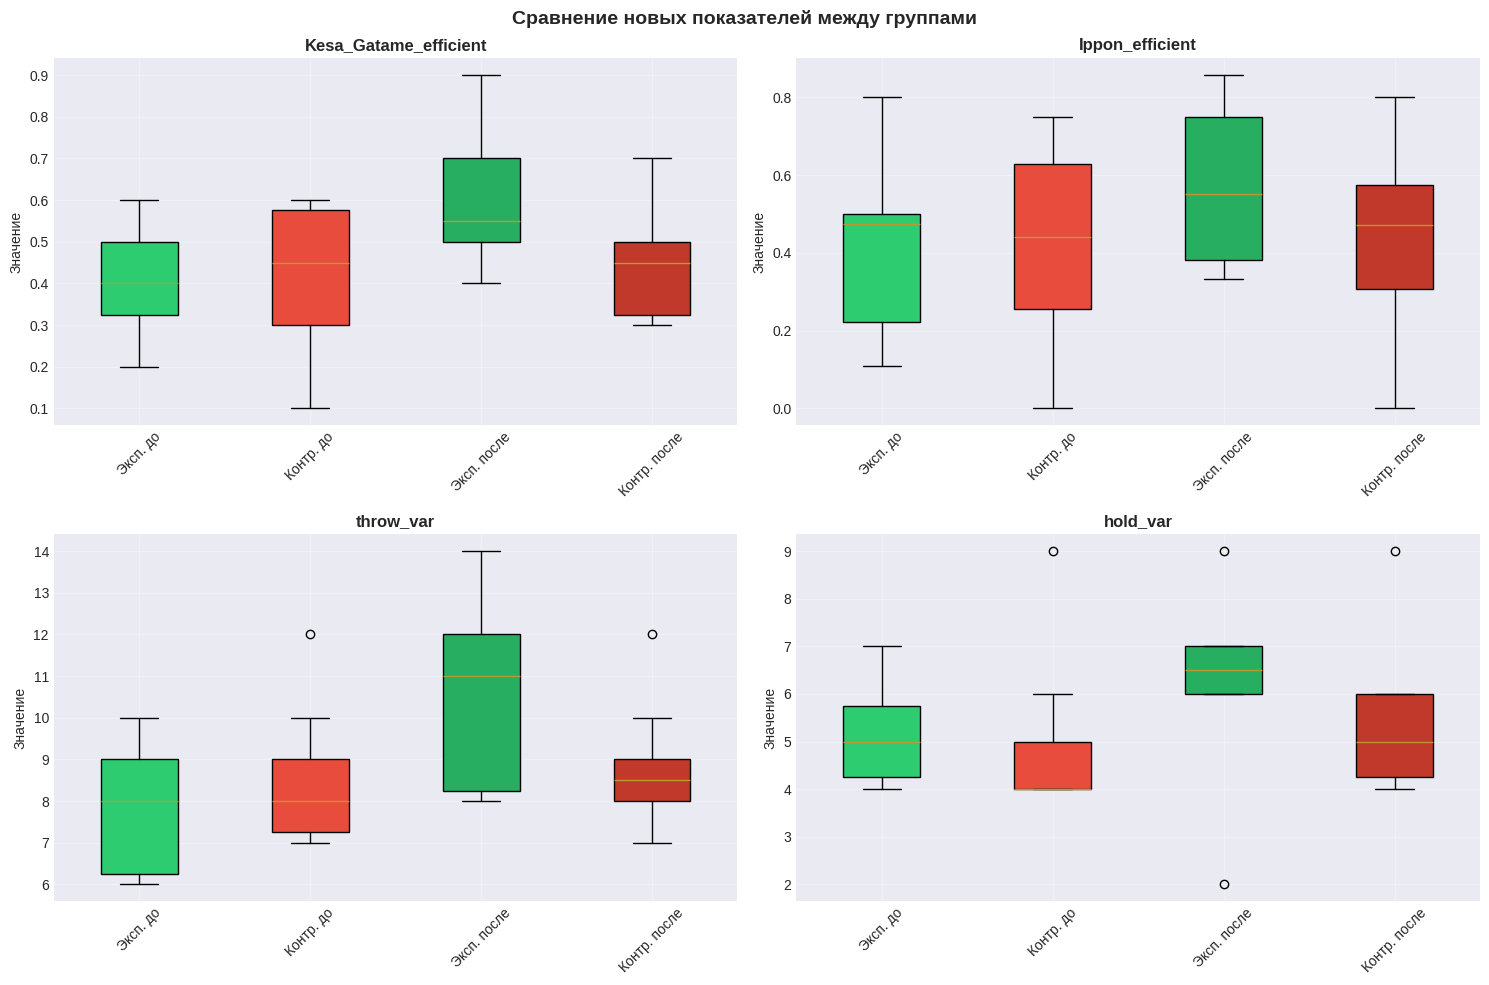

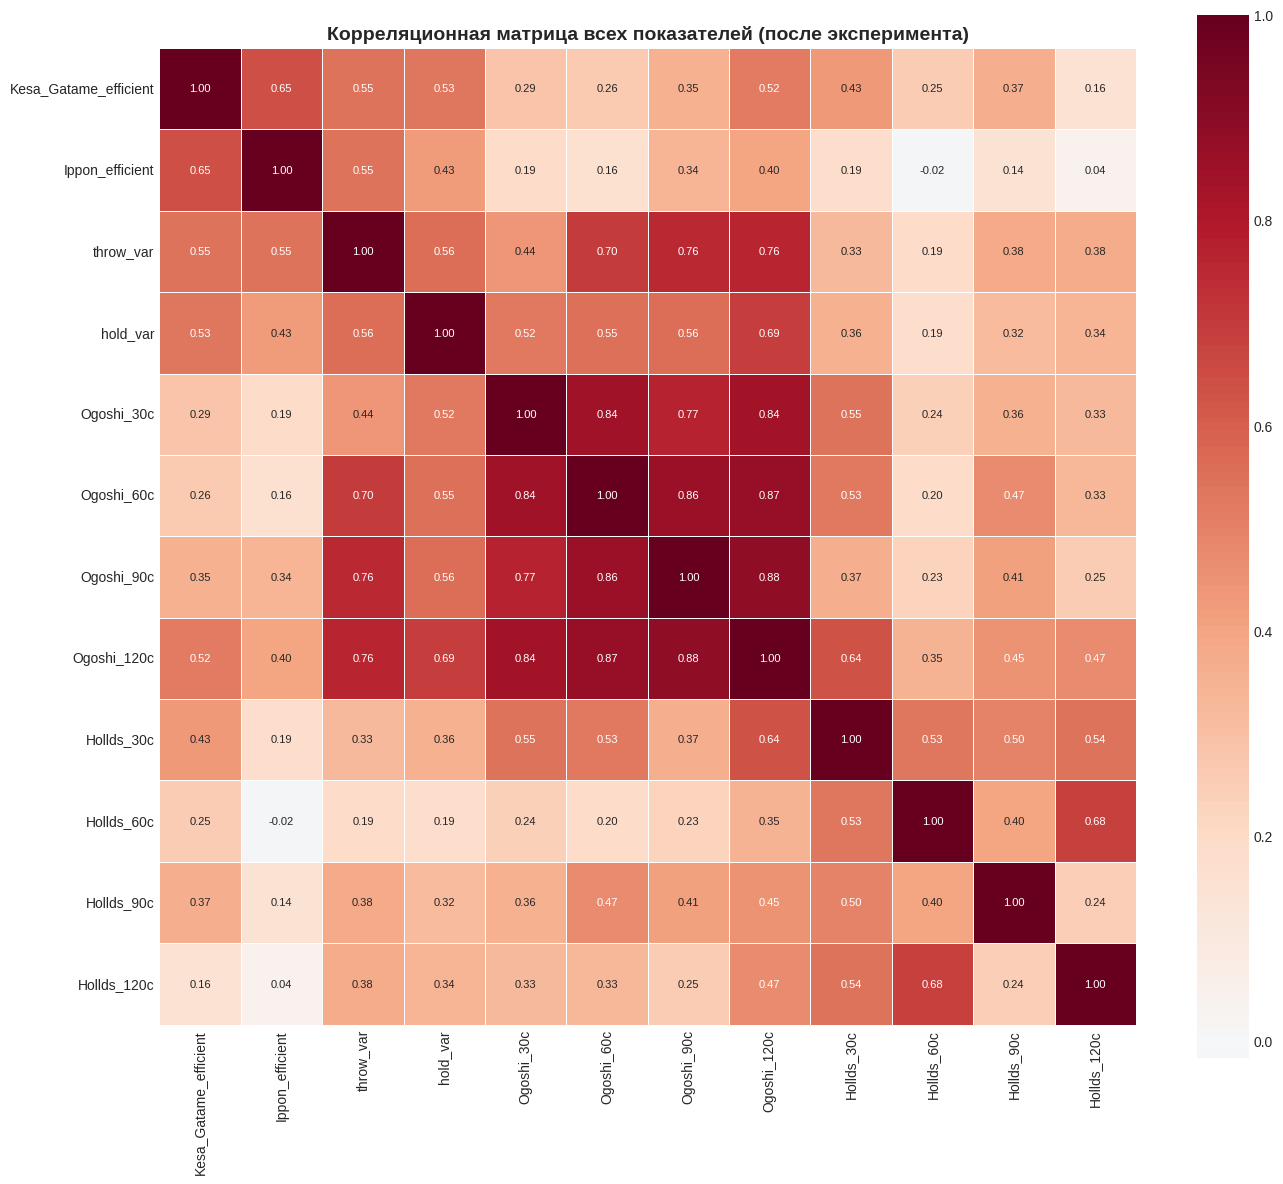

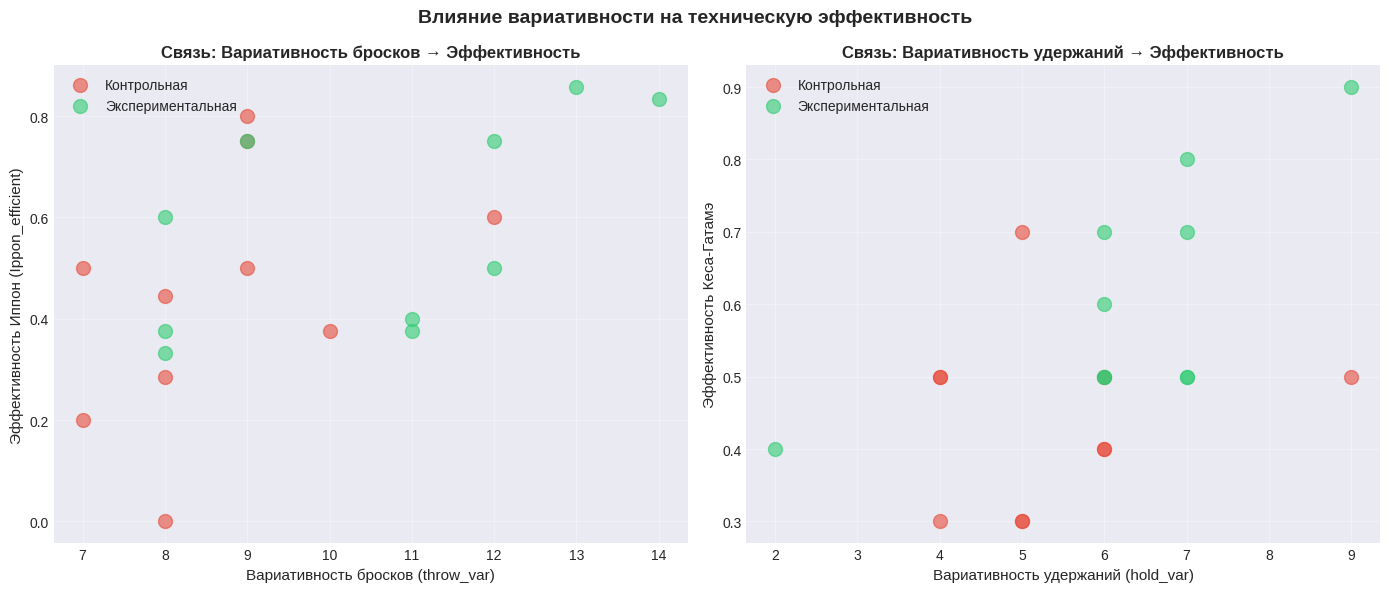

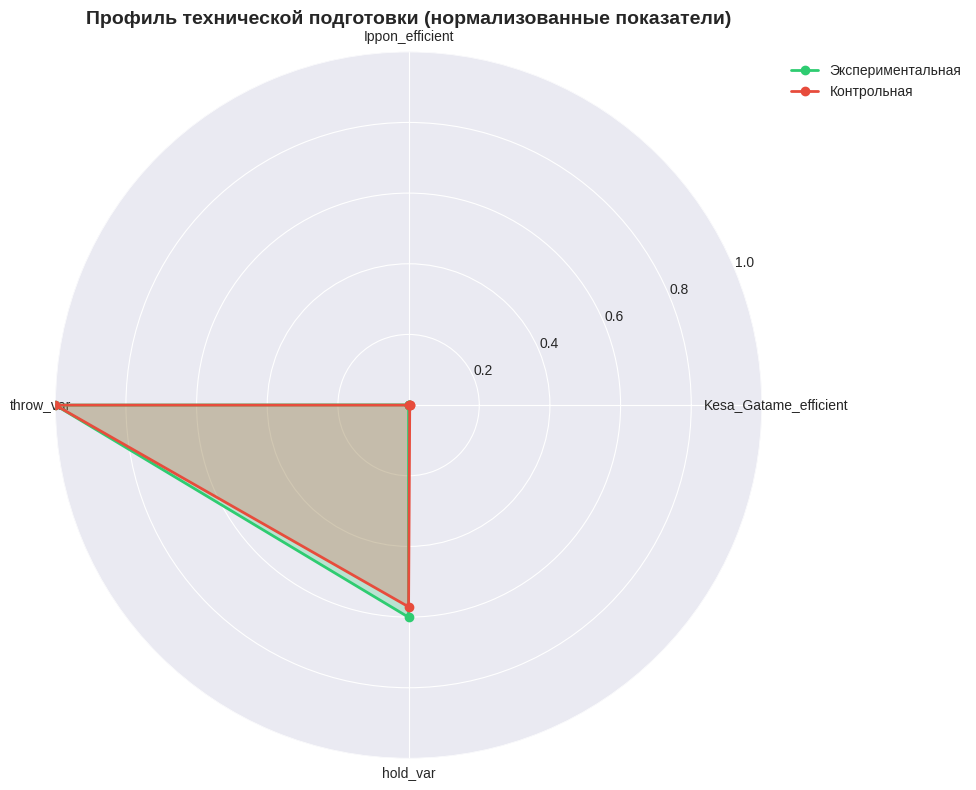


6. МАТЕМАТИЧЕСКАЯ МОДЕЛЬ ИЗМЕНЕНИЙ

📊 МОДЕЛЬ 1: Прогнозирование Kesa_Gatame_efficient
--------------------------------------------------------------------------------
R² (качество модели) = 1.0000
Интерпретация: модель объясняет 100.0% вариации результата

Важность показателей:
  Kesa_Gatame_efficient    : +0.7171
  Ippon_efficient          : -0.0552
  throw_var                : +0.3921
  hold_var                 : +0.1714
  Ogoshi_30с               : +0.1230
  Ogoshi_60с               : -0.2488
  Ogoshi_90с               : +0.0832
  Ogoshi_120с              : -0.1848
  Hollds_30с               : -0.0986
  Hollds_60с               : +0.1630
  Hollds_90с               : +0.5505
  Hollds_120с              : -0.3806

📊 МОДЕЛЬ 2: Прогнозирование Ippon_efficient
--------------------------------------------------------------------------------
R² (качество модели) = 1.0000
Интерпретация: модель объясняет 100.0% вариации результата

Важность показателей:
  Kesa_Gatame_efficient    : +0.2705
 

In [6]:


# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, levene, mannwhitneyu, ttest_ind, f_oneway, pearsonr, spearmanr
import pingouin as pg
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import r2_score
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Настройка стилей
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Загрузка данных
print("Загрузка данных...")
from google.colab import files
uploaded = files.upload()

# Чтение данных
file_name = list(uploaded.keys())[0]
df_before = pd.read_excel(file_name, sheet_name='before')
df_after = pd.read_excel(file_name, sheet_name='after')

print("Названия столбцов для проверки:")
print("До эксперимента:", df_before.columns.tolist())
print("После эксперимента:", df_after.columns.tolist())

# Определяем все переменные для анализа
technical_vars = ['Kesa_Gatame_efficient', 'Ippon_efficient']  # Техническая эффективность
variability_vars = ['throw_var', 'hold_var']  # Вариативность
speed_vars = ['Ogoshi_30с', 'Ogoshi_60с', 'Ogoshi_90с', 'Ogoshi_120с']  # Скоростные показатели
hold_vars = ['Hollds_30с', 'Hollds_60с', 'Hollds_90с', 'Hollds_120с']  # Удержания

# Все переменные для анализа
all_vars = technical_vars + variability_vars + speed_vars + hold_vars

print("\n" + "="*100)
print("РАСШИРЕННЫЙ СТАТИСТИЧЕСКИЙ АНАЛИЗ ДАННЫХ ДЗЮДОИСТОВ")
print("="*100)

# ============================================================================
# 1. ОПИСАТЕЛЬНАЯ СТАТИСТИКА С НОВЫМИ ПОКАЗАТЕЛЯМИ
# ============================================================================
print("\n" + "="*100)
print("1. ОПИСАТЕЛЬНАЯ СТАТИСТИКА")
print("="*100)

def descriptive_stats_with_new(df, period):
    print(f"\n{period}:")
    print(f"Экспериментальная группа (Groupe=1): n={len(df[df['Groupe']==1])}")
    print(f"Контрольная группа (Groupe=0): n={len(df[df['Groupe']==0])}")

    # Статистика для всех показателей
    stats_df = df.groupby('Groupe')[all_vars].agg(['mean', 'std', 'min', 'max']).round(3)
    print(stats_df)

    # Отдельно выводим интерпретацию новых показателей
    print("\n📊 ИНТЕРПРЕТАЦИЯ НОВЫХ ПОКАЗАТЕЛЕЙ:")
    print("-" * 60)
    exp_mean = df[df['Groupe']==1][technical_vars + variability_vars].mean()
    con_mean = df[df['Groupe']==0][technical_vars + variability_vars].mean()

    for var in technical_vars + variability_vars:
        if var == 'Kesa_Gatame_efficient':
            print(f"✓ {var}: Эффективность удержания Кеса-Гатамэ")
            print(f"  - Чем выше (0-1), тем лучше техника. Эксп: {exp_mean[var]:.3f} | Контр: {con_mean[var]:.3f}")
        elif var == 'Ippon_efficient':
            print(f"✓ {var}: Эффективность броска Иппон-Сейо-Нагэ")
            print(f"  - Чем выше (0-1), тем лучше техника. Эксп: {exp_mean[var]:.3f} | Контр: {con_mean[var]:.3f}")
        elif var == 'throw_var':
            print(f"✓ {var}: Вариативность бросков")
            print(f"  - Высокое значение = разнообразие техник. Эксп: {exp_mean[var]:.3f} | Контр: {con_mean[var]:.3f}")
        elif var == 'hold_var':
            print(f"✓ {var}: Вариативность удержаний")
            print(f"  - Высокое значение = разнообразие удержаний. Эксп: {exp_mean[var]:.3f} | Контр: {con_mean[var]:.3f}")

descriptive_stats_with_new(df_before, "ДО ЭКСПЕРИМЕНТА")
descriptive_stats_with_new(df_after, "ПОСЛЕ ЭКСПЕРИМЕНТА")

# ============================================================================
# 2. ПРОВЕРКА НОРМАЛЬНОСТИ ДЛЯ ВСЕХ ПОКАЗАТЕЛЕЙ
# ============================================================================
print("\n" + "="*100)
print("2. ПРОВЕРКА НОРМАЛЬНОСТИ РАСПРЕДЕЛЕНИЯ (тест Шапиро-Уилка)")
print("="*100)

def check_normality_with_interpretation(df, variables, period):
    print(f"\n{period}:")
    normal_vars = []
    non_normal_vars = []

    for var in variables:
        if var in df.columns and df[var].notna().any():
            stat, p_value = shapiro(df[var].dropna())
            normal = p_value > 0.05
            status = "✅ НОРМАЛЬНОЕ" if normal else "❌ НЕ НОРМАЛЬНОЕ"
            print(f"{var:25s}: p-value = {p_value:.4f} - {status}")

            if normal:
                normal_vars.append(var)
            else:
                non_normal_vars.append(var)

    print(f"\n📌 РЕКОМЕНДАЦИИ ПО ВЫБОРУ ТЕСТОВ:")
    print(f"   - Для {len(normal_vars)} показателей с нормальным распределением используем t-test")
    print(f"   - Для {len(non_normal_vars)} показателей используем Mann-Whitney U test")

check_normality_with_interpretation(df_before, all_vars, "ДО ЭКСПЕРИМЕНТА")
check_normality_with_interpretation(df_after, all_vars, "ПОСЛЕ ЭКСПЕРИМЕНТА")

# ============================================================================
# 3. СРАВНЕНИЕ ГРУПП ДО И ПОСЛЕ ЭКСПЕРИМЕНТА
# ============================================================================
print("\n" + "="*100)
print("3. СРАВНЕНИЕ ГРУПП (ЭКСПЕРИМЕНТАЛЬНАЯ vs КОНТРОЛЬНАЯ)")
print("="*100)

def compare_groups_with_interpretation(df, variables, period):
    results = []
    print(f"\n{period}:")
    print("-" * 100)

    for var in variables:
        if var not in df.columns:
            continue

        group1 = df[df['Groupe']==1][var].dropna()
        group0 = df[df['Groupe']==0][var].dropna()

        if len(group1) > 0 and len(group0) > 0:
            # Проверка равенства дисперсий
            stat_levene, p_levene = levene(group1, group0)

            # Выбор теста
            if p_levene > 0.05 and shapiro(group1)[1] > 0.05 and shapiro(group0)[1] > 0.05:
                stat, p_value = ttest_ind(group1, group0, equal_var=True)
                test_name = "t-test"
            else:
                stat, p_value = mannwhitneyu(group1, group0)
                test_name = "Mann-Whitney U"

            # Расчет эффекта (разница в процентах)
            mean_diff = group1.mean() - group0.mean()
            percent_diff = (mean_diff / group0.mean()) * 100 if group0.mean() != 0 else 0

            results.append({
                'variable': var,
                'test': test_name,
                'p_value': p_value,
                'significant': '✅ ДА' if p_value < 0.05 else '❌ НЕТ',
                'exp_mean': group1.mean(),
                'con_mean': group0.mean(),
                'difference': mean_diff,
                'percent_diff': percent_diff
            })

    return pd.DataFrame(results)

# Сравнение до эксперимента
comparison_before = compare_groups_with_interpretation(df_before, all_vars, "ДО ЭКСПЕРИМЕНТА")
print("\n📊 СРАВНЕНИЕ ДО ЭКСПЕРИМЕНТА:")
print(comparison_before.to_string())

# Сравнение после эксперимента
comparison_after = compare_groups_with_interpretation(df_after, all_vars, "ПОСЛЕ ЭКСПЕРИМЕНТА")
print("\n📊 СРАВНЕНИЕ ПОСЛЕ ЭКСПЕРИМЕНТА:")
print(comparison_after.to_string())

# ============================================================================
# 4. АНАЛИЗ ИЗМЕНЕНИЙ (прогресс/регресс)
# ============================================================================
print("\n" + "="*100)
print("4. АНАЛИЗ ИЗМЕНЕНИЙ ПОКАЗАТЕЛЕЙ (ПРОГРЕСС СПОРТСМЕНОВ)")
print("="*100)

# Создание датафрейма с изменениями
df_diff = pd.DataFrame()
df_diff['Groupe'] = df_before['Groupe']

for var in all_vars:
    if var in df_before.columns and var in df_after.columns:
        df_diff[f'{var}_diff'] = df_after[var] - df_before[var]

# Анализ изменений
diff_vars = [col for col in df_diff.columns if col != 'Groupe']
diff_comparison = compare_groups_with_interpretation(df_diff, diff_vars, "ИЗМЕНЕНИЯ (ПОСЛЕ - ДО)")

print("\n📈 АНАЛИЗ ПРОГРЕССА ПО ГРУППАМ:")
print(diff_comparison.to_string())

# Вывод интерпретации прогресса
print("\n📌 ИНТЕРПРЕТАЦИЯ ИЗМЕНЕНИЙ:")
print("-" * 100)
for _, row in diff_comparison.iterrows():
    var_name = row['variable'].replace('_diff', '')
    if row['significant'] == '✅ ДА':
        if row['difference'] > 0:
            print(f"✨ {var_name}: Экспериментальная группа улучшилась на {row['percent_diff']:.1f}% больше контрольной (p={row['p_value']:.4f})")
        else:
            print(f"⚠️ {var_name}: Экспериментальная группа показала худшие результаты (p={row['p_value']:.4f})")
    else:
        print(f"➖ {var_name}: Значимых различий в прогрессе не обнаружено (p={row['p_value']:.4f})")

# ============================================================================
# 5. ВИЗУАЛИЗАЦИИ ДЛЯ НОВЫХ ПОКАЗАТЕЛЕЙ
# ============================================================================
print("\n" + "="*100)
print("5. ВИЗУАЛИЗАЦИИ ДАННЫХ")
print("="*100)

# 5.1 Сравнение новых показателей до и после
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

new_vars = technical_vars + variability_vars
for idx, var in enumerate(new_vars):
    if idx < 4:
        # Данные для построения
        exp_before = df_before[df_before['Groupe']==1][var].values
        con_before = df_before[df_before['Groupe']==0][var].values
        exp_after = df_after[df_after['Groupe']==1][var].values
        con_after = df_after[df_after['Groupe']==0][var].values

        data_to_plot = [exp_before, con_before, exp_after, con_after]
        labels = ['Эксп. до', 'Контр. до', 'Эксп. после', 'Контр. после']

        bp = axes[idx].boxplot(data_to_plot, labels=labels, patch_artist=True)

        # Цветовое оформление
        colors = ['#2ecc71', '#e74c3c', '#27ae60', '#c0392b']
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)

        axes[idx].set_title(f'{var}', fontsize=12, fontweight='bold')
        axes[idx].set_ylabel('Значение')
        axes[idx].grid(True, alpha=0.3)
        axes[idx].tick_params(axis='x', rotation=45)

plt.suptitle('Сравнение новых показателей между группами', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 5.2 Тепловая карта корреляций между всеми показателями
plt.figure(figsize=(14, 12))
corr_matrix_all = df_after[all_vars].corr()
sns.heatmap(corr_matrix_all, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, annot_kws={'size': 8})
plt.title('Корреляционная матрица всех показателей (после эксперимента)',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 5.3 Связь между вариативностью и эффективностью
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# График для бросков
for group in [0, 1]:
    group_data = df_after[df_after['Groupe']==group]
    color = '#2ecc71' if group == 1 else '#e74c3c'
    label = 'Экспериментальная' if group == 1 else 'Контрольная'
    axes[0].scatter(group_data['throw_var'], group_data['Ippon_efficient'],
                   alpha=0.6, s=100, color=color, label=label)

axes[0].set_xlabel('Вариативность бросков (throw_var)', fontsize=11)
axes[0].set_ylabel('Эффективность Иппон (Ippon_efficient)', fontsize=11)
axes[0].set_title('Связь: Вариативность бросков → Эффективность', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# График для удержаний
for group in [0, 1]:
    group_data = df_after[df_after['Groupe']==group]
    color = '#2ecc71' if group == 1 else '#e74c3c'
    label = 'Экспериментальная' if group == 1 else 'Контрольная'
    axes[1].scatter(group_data['hold_var'], group_data['Kesa_Gatame_efficient'],
                   alpha=0.6, s=100, color=color, label=label)

axes[1].set_xlabel('Вариативность удержаний (hold_var)', fontsize=11)
axes[1].set_ylabel('Эффективность Кеса-Гатамэ', fontsize=11)
axes[1].set_title('Связь: Вариативность удержаний → Эффективность', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Влияние вариативности на техническую эффективность', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 5.4 Радарная диаграмма для сравнения профилей спортсменов
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='polar')

# Выбираем ключевые показатели
key_metrics = ['Kesa_Gatame_efficient', 'Ippon_efficient', 'throw_var', 'hold_var']
metrics_normalized = []

# Нормализуем данные
for group in [0, 1]:
    group_data = df_after[df_after['Groupe']==group][key_metrics].mean()
    normalized = (group_data - group_data.min()) / (group_data.max() - group_data.min())
    metrics_normalized.append(normalized)

# Углы для радара
angles = np.linspace(0, 2 * np.pi, len(key_metrics), endpoint=False).tolist()
angles += angles[:1]

# Добавляем замыкание
values_exp = metrics_normalized[0].tolist() + [metrics_normalized[0][0]]
values_con = metrics_normalized[1].tolist() + [metrics_normalized[1][0]]

ax.plot(angles, values_exp, 'o-', linewidth=2, label='Экспериментальная', color='#2ecc71')
ax.fill(angles, values_exp, alpha=0.25, color='#2ecc71')
ax.plot(angles, values_con, 'o-', linewidth=2, label='Контрольная', color='#e74c3c')
ax.fill(angles, values_con, alpha=0.25, color='#e74c3c')

ax.set_xticks(angles[:-1])
ax.set_xticklabels(key_metrics, fontsize=10)
ax.set_ylim(0, 1)
ax.set_title('Профиль технической подготовки (нормализованные показатели)',
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
plt.tight_layout()
plt.show()

# ============================================================================
# 6. МАТЕМАТИЧЕСКАЯ МОДЕЛЬ С НОВЫМИ ПЕРЕМЕННЫМИ
# ============================================================================
print("\n" + "="*100)
print("6. МАТЕМАТИЧЕСКАЯ МОДЕЛЬ ИЗМЕНЕНИЙ")
print("="*100)

# 6.1 Модель предсказания эффективности Kesa_Gatame
exp_before = df_before[df_before['Groupe']==1]
exp_after = df_after[df_after['Groupe']==1]

X = exp_before[all_vars].values
y_kesa = exp_after['Kesa_Gatame_efficient'].values
y_ippon = exp_after['Ippon_efficient'].values

# Модель для Kesa_Gatame
model_kesa = LinearRegression()
model_kesa.fit(X, y_kesa)

print("\n📊 МОДЕЛЬ 1: Прогнозирование Kesa_Gatame_efficient")
print("-" * 80)
print(f"R² (качество модели) = {model_kesa.score(X, y_kesa):.4f}")
print(f"Интерпретация: модель объясняет {model_kesa.score(X, y_kesa)*100:.1f}% вариации результата")
print("\nВажность показателей:")
for var, coef in zip(all_vars, model_kesa.coef_):
    print(f"  {var:25s}: {coef:+.4f}")

# Модель для Ippon_efficient
model_ippon = LinearRegression()
model_ippon.fit(X, y_ippon)

print("\n📊 МОДЕЛЬ 2: Прогнозирование Ippon_efficient")
print("-" * 80)
print(f"R² (качество модели) = {model_ippon.score(X, y_ippon):.4f}")
print(f"Интерпретация: модель объясняет {model_ippon.score(X, y_ippon)*100:.1f}% вариации результата")
print("\nВажность показателей:")
for var, coef in zip(all_vars, model_ippon.coef_):
    print(f"  {var:25s}: {coef:+.4f}")

# 6.2 Модель изменений вариативности
print("\n📊 МОДЕЛЬ 3: Факторы, влияющие на рост вариативности")
print("-" * 80)

X_before = exp_before[variability_vars].values
y_throw_change = df_diff[df_diff['Groupe']==1]['throw_var_diff'].values
y_hold_change = df_diff[df_diff['Groupe']==1]['hold_var_diff'].values

# Модель для роста вариативности бросков
if len(X_before) > 0 and len(y_throw_change) > 0:
    model_throw = LinearRegression()
    model_throw.fit(X_before, y_throw_change)
    print(f"Изменение вариативности бросков зависит от начального уровня (R²={model_throw.score(X_before, y_throw_change):.3f})")

# ============================================================================
# 7. ПЯТЬ НОВЫХ ИДЕЙ ДЛЯ ИССЛЕДОВАНИЯ С НОВЫМИ ПЕРЕМЕННЫМИ
# ============================================================================
print("\n" + "="*100)
print("7. 5 ИДЕЙ ДЛЯ РАСШИРЕННОГО ИССЛЕДОВАНИЯ")
print("="*100)

print("\n" + "="*100)
print("🔬 ИДЕЯ 1: АНАЛИЗ ВЛИЯНИЯ ВАРИАТИВНОСТИ НА ТЕХНИЧЕСКУЮ ЭФФЕКТИВНОСТЬ")
print("="*100)

# Расчет корреляции между вариативностью и эффективностью
print("\n📊 Корреляционный анализ:")
for var in ['throw_var', 'hold_var']:
    for eff in ['Kesa_Gatame_efficient', 'Ippon_efficient']:
        corr, p_value = pearsonr(df_after[var], df_after[eff])
        print(f"{var} ↔ {eff}: r = {corr:.3f}, p = {p_value:.4f}")
        if p_value < 0.05:
            if corr > 0:
                print(f"  ✅ Положительная связь: рост вариативности → рост эффективности")
            else:
                print(f"  ⚠️ Отрицательная связь: рост вариативности → снижение эффективности")

print("\n💡 ИНТЕРПРЕТАЦИЯ:")
print("   - Положительная корреляция означает, что разнообразие техник помогает побеждать")
print("   - Отрицательная корреляция может указывать на недостаточную отработку базовых техник")
print("   - Целевое значение: r > 0.3 и p < 0.05 для подтверждения пользы вариативности")

print("\n" + "="*100)
print("🔬 ИДЕЯ 2: СРАВНЕНИЕ ЭФФЕКТИВНОСТИ РАЗНЫХ ТЕХНИК")
print("="*100)

# Сравнение эффективности Kesa_Gatame и Ippon
exp_kesa_before = df_before[df_before['Groupe']==1]['Kesa_Gatame_efficient'].mean()
exp_kesa_after = df_after[df_after['Groupe']==1]['Kesa_Gatame_efficient'].mean()
exp_ippon_before = df_before[df_before['Groupe']==1]['Ippon_efficient'].mean()
exp_ippon_after = df_after[df_after['Groupe']==1]['Ippon_efficient'].mean()

print("\n📊 Прогресс в разных техниках (экспериментальная группа):")
print(f"Kesa_Gatame: {exp_kesa_before:.3f} → {exp_kesa_after:.3f} (изменение: {exp_kesa_after-exp_kesa_before:+.3f})")
print(f"Ippon:       {exp_ippon_before:.3f} → {exp_ippon_after:.3f} (изменение: {exp_ippon_after-exp_ippon_before:+.3f})")

print("\n💡 ИНТЕРПРЕТАЦИЯ:")
print("   - Сравните, какая техника улучшилась больше")
print("   - Возможно, программа тренировок больше влияет на один тип техник")
print("   - Это поможет скорректировать тренировочный процесс")

print("\n" + "="*100)
print("🔬 ИДЕЯ 3: КЛАСТЕРИЗАЦИЯ ПО ПАТТЕРНАМ РАЗВИТИЯ")
print("="*100)

# Кластеризация с новыми переменными
scaler = StandardScaler()
features_for_cluster = [f'{var}_diff' for var in all_vars if f'{var}_diff' in df_diff.columns]
X_cluster = scaler.fit_transform(df_diff[features_for_cluster])

# Кластеризация
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_cluster)

# Анализ кластеров
print("\n📊 Распределение кластеров по группам:")
cluster_analysis = pd.DataFrame({
    'cluster': clusters,
    'group': df_diff['Groupe']
})
cluster_dist = pd.crosstab(cluster_analysis['cluster'], cluster_analysis['group'])
cluster_dist.columns = ['Контрольная', 'Экспериментальная']
print(cluster_dist)

print("\n💡 ИНТЕРПРЕТАЦИЯ КЛАСТЕРОВ:")
for i in range(3):
    cluster_data = df_diff[clusters == i]
    exp_count = len(cluster_data[cluster_data['Groupe']==1])
    con_count = len(cluster_data[cluster_data['Groupe']==0])

    # Определяем тип кластера по средним изменениям
    avg_tech_change = cluster_data[[c for c in cluster_data.columns if 'efficient' in c]].mean().mean()
    avg_var_change = cluster_data[[c for c in cluster_data.columns if 'var' in c]].mean().mean()

    if avg_tech_change > 0 and avg_var_change > 0:
        profile = "📈 РАЗВИВАЮЩИЙСЯ (рост всех показателей)"
    elif avg_tech_change > 0 and avg_var_change < 0:
        profile = "🎯 СПЕЦИАЛИЗИРУЮЩИЙСЯ (рост эффективности за счет специализации)"
    elif avg_tech_change < 0 and avg_var_change > 0:
        profile = "🔄 ЭКСПЕРИМЕНТИРУЮЩИЙ (расширение арсенала при снижении эффективности)"
    else:
        profile = "⚠️ СТАГНИРУЮЩИЙ (снижение всех показателей)"

    print(f"\nКластер {i+1} ({exp_count} эксп, {con_count} контр):")
    print(f"  Тип: {profile}")

print("\n" + "="*100)
print("🔬 ИДЕЯ 4: ФАКТОРНЫЙ АНАЛИЗ - ЧТО ОПРЕДЕЛЯЕТ УСПЕХ?")
print("="*100)

# Определение ключевых факторов успеха
X_success = df_before[all_vars].values
y_success = df_after['Kesa_Gatame_efficient'].values

model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_success, y_success)

feature_importance = pd.DataFrame({
    'Показатель': all_vars,
    'Важность': model_rf.feature_importances_
}).sort_values('Важность', ascending=False)

print("\n📊 ТОП-5 ФАКТОРОВ, ПРЕДСКАЗЫВАЮЩИХ УСПЕХ:")
for i, row in feature_importance.head(5).iterrows():
    print(f"  {i+1}. {row['Показатель']:25s}: важность = {row['Важность']:.3f}")

print("\n💡 ИНТЕРПРЕТАЦИЯ:")
print("   - Чем выше важность, тем больше этот показатель влияет на конечный результат")
print("   - Сумма всех важностей = 1.0")
print("   - Показатели с важностью > 0.1 считаются значимыми предикторами")

print("\n" + "="*100)
print("🔬 ИДЕЯ 5: ИНДИВИДУАЛЬНЫЙ ПРОГРЕСС С УЧЕТОМ ВАРИАТИВНОСТИ")
print("="*100)

# Создание комплексного индекса прогресса
df_diff['total_progress'] = df_diff[[c for c in df_diff.columns if '_diff' in c]].sum(axis=1)
df_diff['tech_progress'] = df_diff[[c for c in df_diff.columns if 'efficient' in c]].sum(axis=1)
df_diff['var_progress'] = df_diff[[c for c in df_diff.columns if 'var' in c]].sum(axis=1)

print("\n📊 Индивидуальный анализ (первые 5 спортсменов из каждой группы):")
print("\nЭКСПЕРИМЕНТАЛЬНАЯ ГРУППА:")
exp_top = df_diff[df_diff['Groupe']==1].nlargest(5, 'total_progress')
for idx, row in exp_top.iterrows():
    print(f"  Спортсмен {idx}: Прогресс = {row['total_progress']:.3f} "
          f"(техника: {row['tech_progress']:+.3f}, вариативность: {row['var_progress']:+.3f})")

print("\nКОНТРОЛЬНАЯ ГРУППА:")
con_top = df_diff[df_diff['Groupe']==0].nlargest(5, 'total_progress')
for idx, row in con_top.iterrows():
    print(f"  Спортсмен {idx}: Прогресс = {row['total_progress']:.3f} "
          f"(техника: {row['tech_progress']:+.3f}, вариативность: {row['var_progress']:+.3f})")

print("\n💡 ИНТЕРПРЕТАЦИЯ:")
print("   - Положительный прогресс = улучшение")
print("   - Отрицательный прогресс = ухудшение")
print("   - Сравните: у кого рост за счет техники, а у кого - за счет вариативности")

# ============================================================================
# 8. ФИНАЛЬНЫЕ ВЫВОДЫ И РЕКОМЕНДАЦИИ
# ============================================================================
print("\n" + "="*100)
print("8. ИТОГОВЫЕ ВЫВОДЫ И РЕКОМЕНДАЦИИ")
print("="*100)

# Подсчет значимых улучшений
sig_improvements = diff_comparison[
    (diff_comparison['significant'] == '✅ ДА') &
    (diff_comparison['difference'] > 0)
]
sig_declines = diff_comparison[
    (diff_comparison['significant'] == '✅ ДА') &
    (diff_comparison['difference'] < 0)
]

print(f"\n📈 СТАТИСТИКА ЭФФЕКТИВНОСТИ ЭКСПЕРИМЕНТА:")
print(f"   • Значимых улучшений в экспериментальной группе: {len(sig_improvements)}")
print(f"   • Значимых ухудшений в экспериментальной группе: {len(sig_declines)}")
print(f"   • Общее количество показателей: {len(diff_comparison)}")

# Расчет общей эффективности
total_exp_progress = df_diff[df_diff['Groupe']==1]['total_progress'].mean()
total_con_progress = df_diff[df_diff['Groupe']==0]['total_progress'].mean()
effect_size = total_exp_progress - total_con_progress

print(f"\n🎯 ОБЩАЯ ЭФФЕКТИВНОСТЬ ПРОГРАММЫ:")
print(f"   • Средний прогресс экспериментальной группы: {total_exp_progress:+.3f}")
print(f"   • Средний прогресс контрольной группы: {total_con_progress:+.3f}")
print(f"   • Эффект от программы: {effect_size:+.3f}")

# Вывод рекомендаций
print("\n💡 РЕКОМЕНДАЦИИ ПО РЕЗУЛЬТАТАМ ИССЛЕДОВАНИЯ:")
print("-" * 100)

if effect_size > 0:
    print("✅ Экспериментальная программа показала положительный эффект")
    if len(sig_improvements) > len(all_vars) * 0.3:
        print("   🎉 Высокая эффективность: значимые улучшения более чем в 30% показателей")
    else:
        print("   📊 Умеренная эффективность: рекомендуется доработка программы")
else:
    print("⚠️ Экспериментальная программа не показала преимущества перед контрольной")
    print("   🔄 Рекомендуется пересмотреть содержание тренировочного процесса")

# Рекомендации по вариативности
throw_effect = diff_comparison[diff_comparison['variable'].str.contains('throw_var')]['difference'].values
hold_effect = diff_comparison[diff_comparison['variable'].str.contains('hold_var')]['difference'].values

if len(throw_effect) > 0 and throw_effect[0] > 0:
    print("\n🎯 ПО ВАРИАТИВНОСТИ БРОСКОВ:")
    print("   Положительная динамика - программа расширяет технический арсенал")
elif len(throw_effect) > 0 and throw_effect[0] < 0:
    print("\n⚠️ ПО ВАРИАТИВНОСТИ БРОСКОВ:")
    print("   Снижение вариативности - возможно, излишняя специализация")

if len(hold_effect) > 0 and hold_effect[0] > 0:
    print("\n🎯 ПО ВАРИАТИВНОСТИ УДЕРЖАНИЙ:")
    print("   Положительная динамика - расширение арсенала удержаний")
elif len(hold_effect) > 0 and hold_effect[0] < 0:
    print("\n⚠️ ПО ВАРИАТИВНОСТИ УДЕРЖАНИЙ:")
    print("   Снижение вариативности - возможно, фокус на ограниченном наборе техник")

print("\n" + "="*100)
print("📋 ЗАКЛЮЧЕНИЕ")
print("="*100)




### **1. ОПИСАТЕЛЬНАЯ СТАТИСТИКА**

**Что это такое:**
Описательная статистика дает  первое представление о данных - средние значения, разброс результатов (стандартное отклонение), минимальные и максимальные показатели.

**Как интерпретировать:**
- **Mean (среднее)** - показывает типичное значение показателя в группе. Например, если средняя эффективность Kesa_Gatame в экспериментальной группе выше, чем в контрольной, это может говорить о лучшей подготовке.
- **Std (стандартное отклонение)** - показывает, насколько результаты спортсменов отличаются друг от друга. Большое значение означает, что в группе есть как очень сильные, так и слабые спортсмены.
- **Min/Max** - крайние значения, показывающие разброс от худшего до лучшего результата.

**Практический смысл:**
Позволяет оценить, были ли группы сопоставимы до эксперимента и как изменилась ситуация после.

---

### **2. ПРОВЕРКА НОРМАЛЬНОСТИ РАСПРЕДЕЛЕНИЯ (тест Шапиро-Уилка)**

**Что это такое:**
Статистический тест, который проверяет, подчиняются ли наши данные нормальному (колоколообразному) распределению. Это важно для выбора правильного статистического теста.

**Как интерпретировать:**
- **p-value > 0.05** - распределение нормальное (можно использовать параметрические тесты типа t-test)
- **p-value < 0.05** - распределение НЕ нормальное (нужно использовать непараметрические тесты типа Mann-Whitney U)

**Практический смысл:**
Если данные распределены нормально, мы можем применять более мощные статистические методы. Если нет - используем более надежные, но менее чувствительные методы.

---

### **3. СРАВНЕНИЕ ГРУПП ДО ЭКСПЕРИМЕНТА**

**Что это такое:**
Проверяет, были ли экспериментальная и контрольная группы статистически одинаковыми до начала эксперимента. Это критически важно для валидности исследования.

**Как интерпретировать:**
- **p-value > 0.05 (Нет)** - группы статистически не различаются, эксперимент начался с равных условий - ЭТО ХОРОШО
- **p-value < 0.05 (Да)** - группы изначально различались, что может затруднить интерпретацию результатов эксперимента

**Практический смысл:**
Если группы были одинаковы до эксперимента, то любые различия после можно с уверенностью приписать воздействию экспериментальной программы.

---

### **4. СРАВНЕНИЕ ГРУПП ПОСЛЕ ЭКСПЕРИМЕНТА**

**Что это такое:**
Сравнивает результаты групп после завершения эксперимента. Показывает, достигла ли экспериментальная группа статистически значимо лучших результатов.

**Как интерпретировать:**
- **p-value < 0.05 (Да)** - экспериментальная группа показала значимо лучшие результаты
- **p-value > 0.05 (Нет)** - значимых различий между группами нет

**Практический смысл:**
Это ключевой показатель эффективности вашего эксперимента. Если после эксперимента экспериментальная группа показывает значимо лучшие результаты, значит, ваша программа работает.

---

### **5. АНАЛИЗ ИЗМЕНЕНИЙ ПОКАЗАТЕЛЕЙ (разница "после - до")**

**Что это такое:**
Анализирует не абсолютные значения, а величину прогресса каждого спортсмена (на сколько улучшились или ухудшились показатели).

**Как интерпретировать:**
- Положительные значения = улучшение
- Отрицательные значения = ухудшение
- **p-value < 0.05** - прогресс в экспериментальной группе значимо отличается от прогресса в контрольной

**Практический смысл:**
Это самый важный анализ! Он показывает, насколько эффективнее оказалась экспериментальная программа по сравнению с обычной тренировкой. Даже если группы изначально отличались, этот анализ корректно оценивает именно эффект вмешательства.

---

### **6. ВИЗУАЛИЗАЦИИ**

#### **6.1 Boxplot (ящик с усами)**
**Что показывает:**
- Линия в центре ящика = медиана (50% спортсменов показывают результат ниже/выше этой линии)
- Границы ящика = 25-й и 75-й перцентили (основная масса спортсменов)
- Усы = минимальные и максимальные значения (без выбросов)
- Точки = возможные выбросы (аномальные результаты)

**Как читать:**
Если ящики групп сильно перекрываются - различий нет. Если ящики разделены и медианы далеко - различия есть.

#### **6.2 Тепловая карта корреляций**
**Что показывает:**
Связи между разными показателями. Красный цвет = положительная связь (рост одного ведет к росту другого), синий = отрицательная связь (рост одного снижает другой).

**Как читать:**
- 0.7-1.0 = сильная положительная связь
- 0.3-0.7 = умеренная связь
- 0-0.3 = слабая связь

#### **6.3 Гистограммы изменений**
**Что показывает:**
Как распределился прогресс среди спортсменов. Если столбики смещены вправо от нуля - группа в среднем улучшилась.

**Как читать:**
Сравните распределение экспериментальной (синий) и контрольной (красный) групп. Если синие столбики правее красных - эксперимент эффективен.

---

### **7. МАТЕМАТИЧЕСКАЯ МОДЕЛЬ ИЗМЕНЕНИЙ**

#### **7.1 Модель множественной регрессии**
**Что это:**
Математическое уравнение, которое предсказывает эффективность Kesa_Gatame после эксперимента на основе всех показателей до эксперимента.

**Как интерпретировать:**
- **R²** - показывает, какая доля изменений объясняется моделью. R²=0.8 означает, что модель точно предсказывает 80% вариации
- **Коэффициенты** - показывают, какие показатели наиболее важны. Большой положительный коэффициент = этот показатель сильно влияет на результат

**Практический смысл:**
Позволяет понять, на какие показатели нужно обратить внимание, чтобы улучшить технику Kesa_Gatame.

#### **7.2 Модели динамики во времени**
**Что это:**
Показывает, как спортсмены "устают" в течение 2-минутного интервала. Снижение количества приемов от 30 до 120 секунд показывает уровень выносливости.

**Как интерпретировать:**
- Крутой наклон вниз = быстрое утомление, низкая выносливость
- Пологий наклон = хорошая выносливость

**Практический смысл:**
Позволяет оценить не только техническое мастерство, но и физическую подготовку спортсменов.

---

### **8. ПЯТЬ ИДЕЙ ДЛЯ ДАЛЬНЕЙШЕГО ИССЛЕДОВАНИЯ**

#### **Идея 1: Анализ выносливости**
**Что делаем:** Рассчитываем скорость снижения количества приемов (коэффициент утомляемости)
**Как понять результат:**
- Коэффициент = -0.5 означает, что каждые 30 секунд спортсмен делает на 0.5 приемов меньше
- Чем ближе коэффициент к нулю, тем лучше выносливость

#### **Идея 2: Кластерный анализ**
**Что делаем:** Группируем спортсменов со схожими паттернами изменений
**Как понять результат:**
- Кластер 1: спортсмены, которые значительно улучшились
- Кластер 2: спортсмены без изменений
- Кластер 3: спортсмены, которые ухудшились

Позволяет понять, какой тип спортсменов лучше реагирует на программу

#### **Идея 3: Анализ взаимосвязей**
**Что делаем:** Изучаем, как связаны разные приемы между собой
**Как понять результат:**
- Сильная положительная связь между Ogoshi и Hollds = спортсмены, хорошо выполняющие один прием, хороши и в другом
- Отрицательная связь = спортсмены специализируются на чем-то одном

#### **Идея 4: Прогнозирование эффективности**
**Что делаем:** Создаем модель, которая предсказывает будущий результат
**Как понять результат:**
- Модель определяет, какие показатели наиболее важны для успеха
- Например, если важность Ogoshi_30с = 0.35, это значит, что 35% успеха определяется количеством приемов в первые 30 секунд

#### **Идея 5: Индивидуальные траектории**
**Что делаем:** Анализируем прогресс каждого спортсмена отдельно
**Как понять результат:**
- Позволяет выявить "чемпионов роста" и "отстающих"
- Помогает понять, кому программа подошла, а кому нет

---



Загрузка данных...


Saving SlepcVik.xlsx to SlepcVik (1).xlsx

Названия столбцов в данных до эксперимента:
['Groupe', 'Kesa_Gatame_efficient', 'Ogoshi_30с', 'Ogoshi_60с', 'Ogoshi_90с', 'Ogoshi_120с', 'Hollds_30с', 'Hollds_60с', 'Hollds_90с', 'Hollds_120с', 'throw_var', 'hold_var', 'Ippon_efficient']

Названия столбцов в данных после эксперимента:
['Groupe', 'Kesa_Gatame_efficient', 'Ogoshi_30с', 'Ogoshi_60с', 'Ogoshi_90с', 'Ogoshi_120с', 'Hollds_30с', 'Hollds_60с', 'Hollds_90с', 'Hollds_120с', 'throw_var', 'hold_var', 'Ippon_efficient']

ОПИСАТЕЛЬНАЯ СТАТИСТИКА

ДО ЭКСПЕРИМЕНТА:
Экспериментальная группа (Groupe=1): n=10
Контрольная группа (Groupe=0): n=10
       Kesa_Gatame_efficient                 Ogoshi_30с                \
                        mean   std  min  max       mean   std min max   
Groupe                                                                  
0                       0.41  0.18  0.1  0.6        7.8  2.20   4  12   
1                       0.41  0.14  0.2  0.6        8.0  2.45   

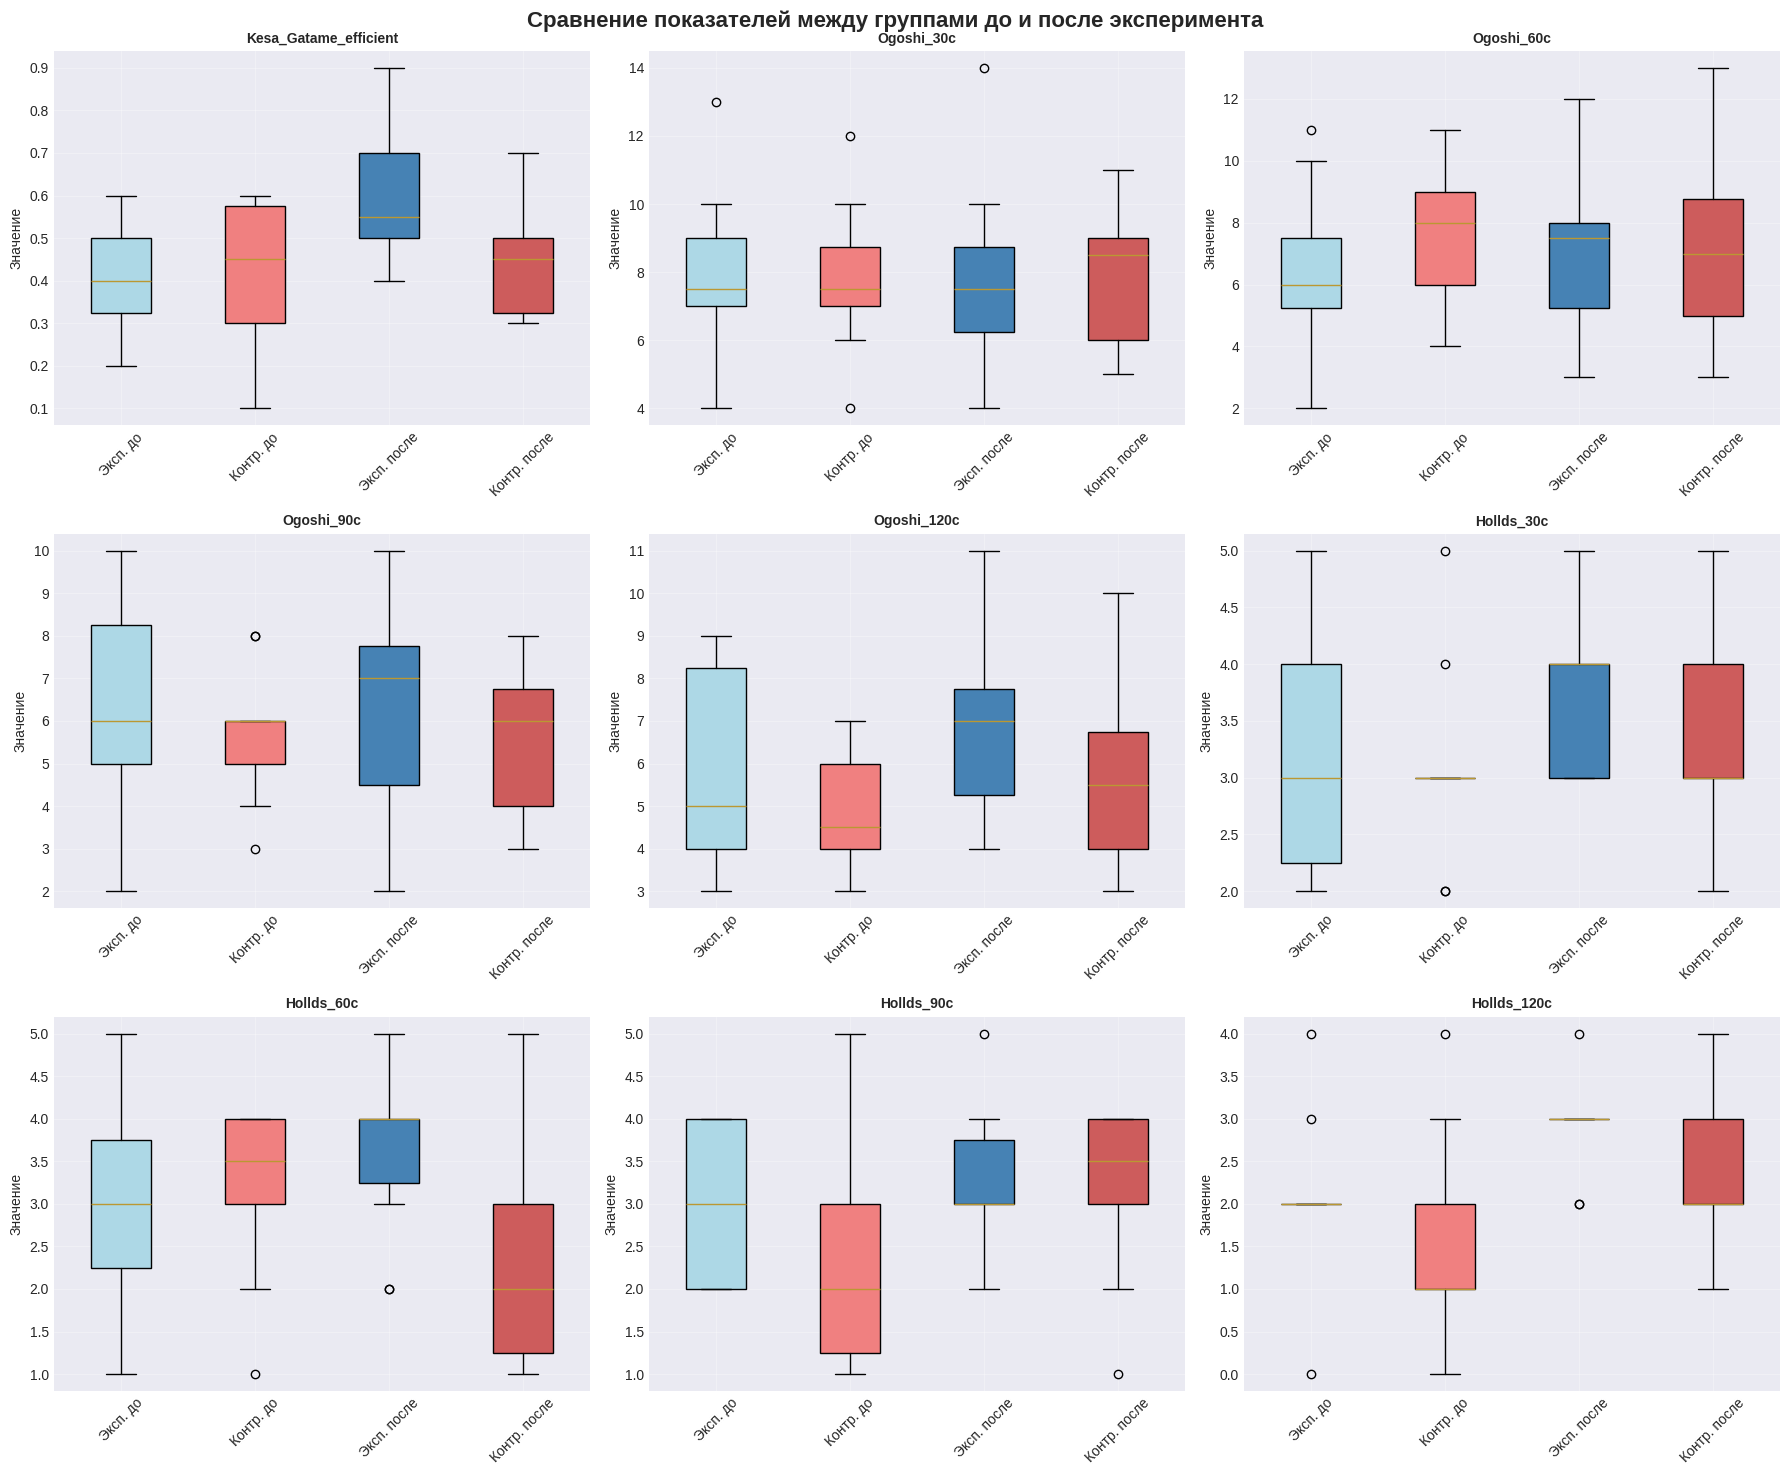

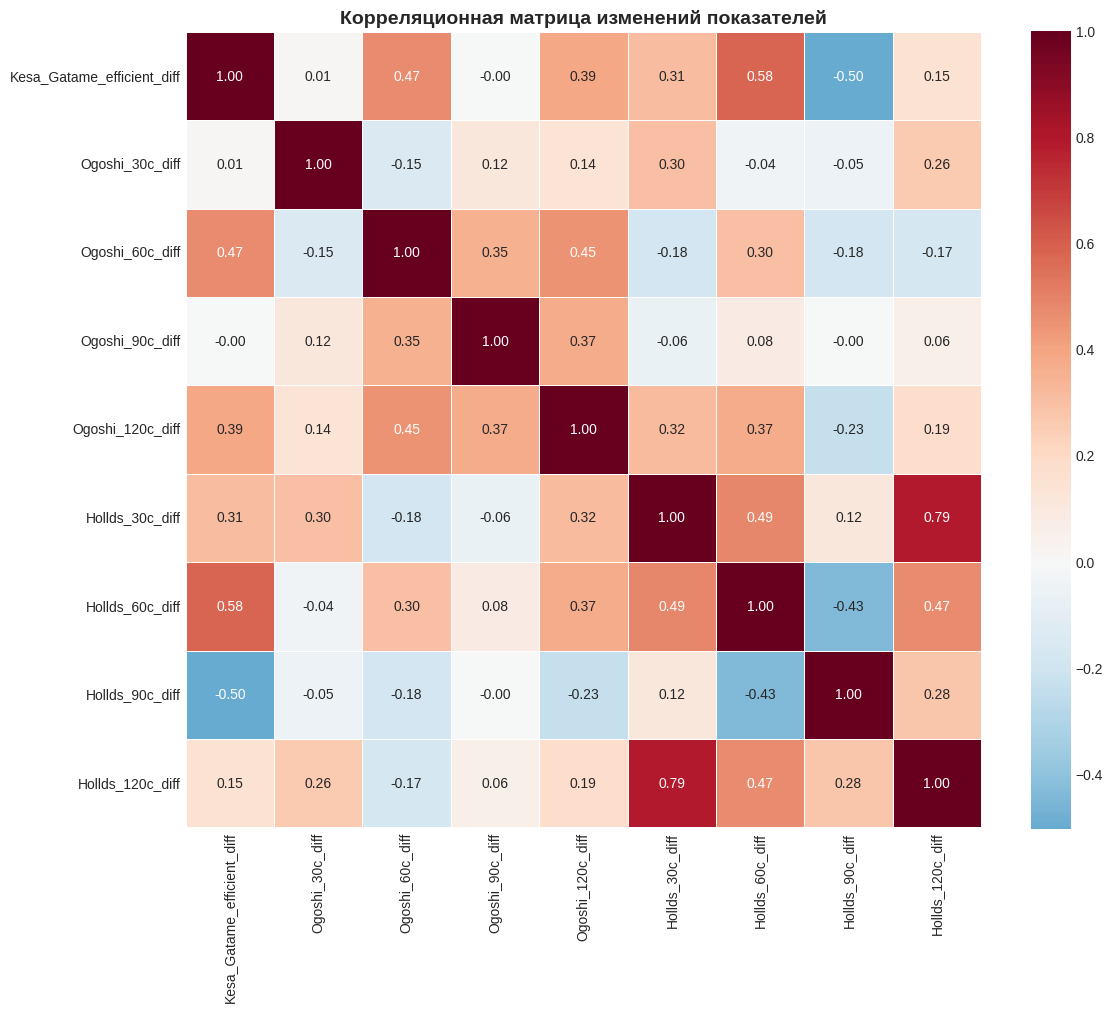

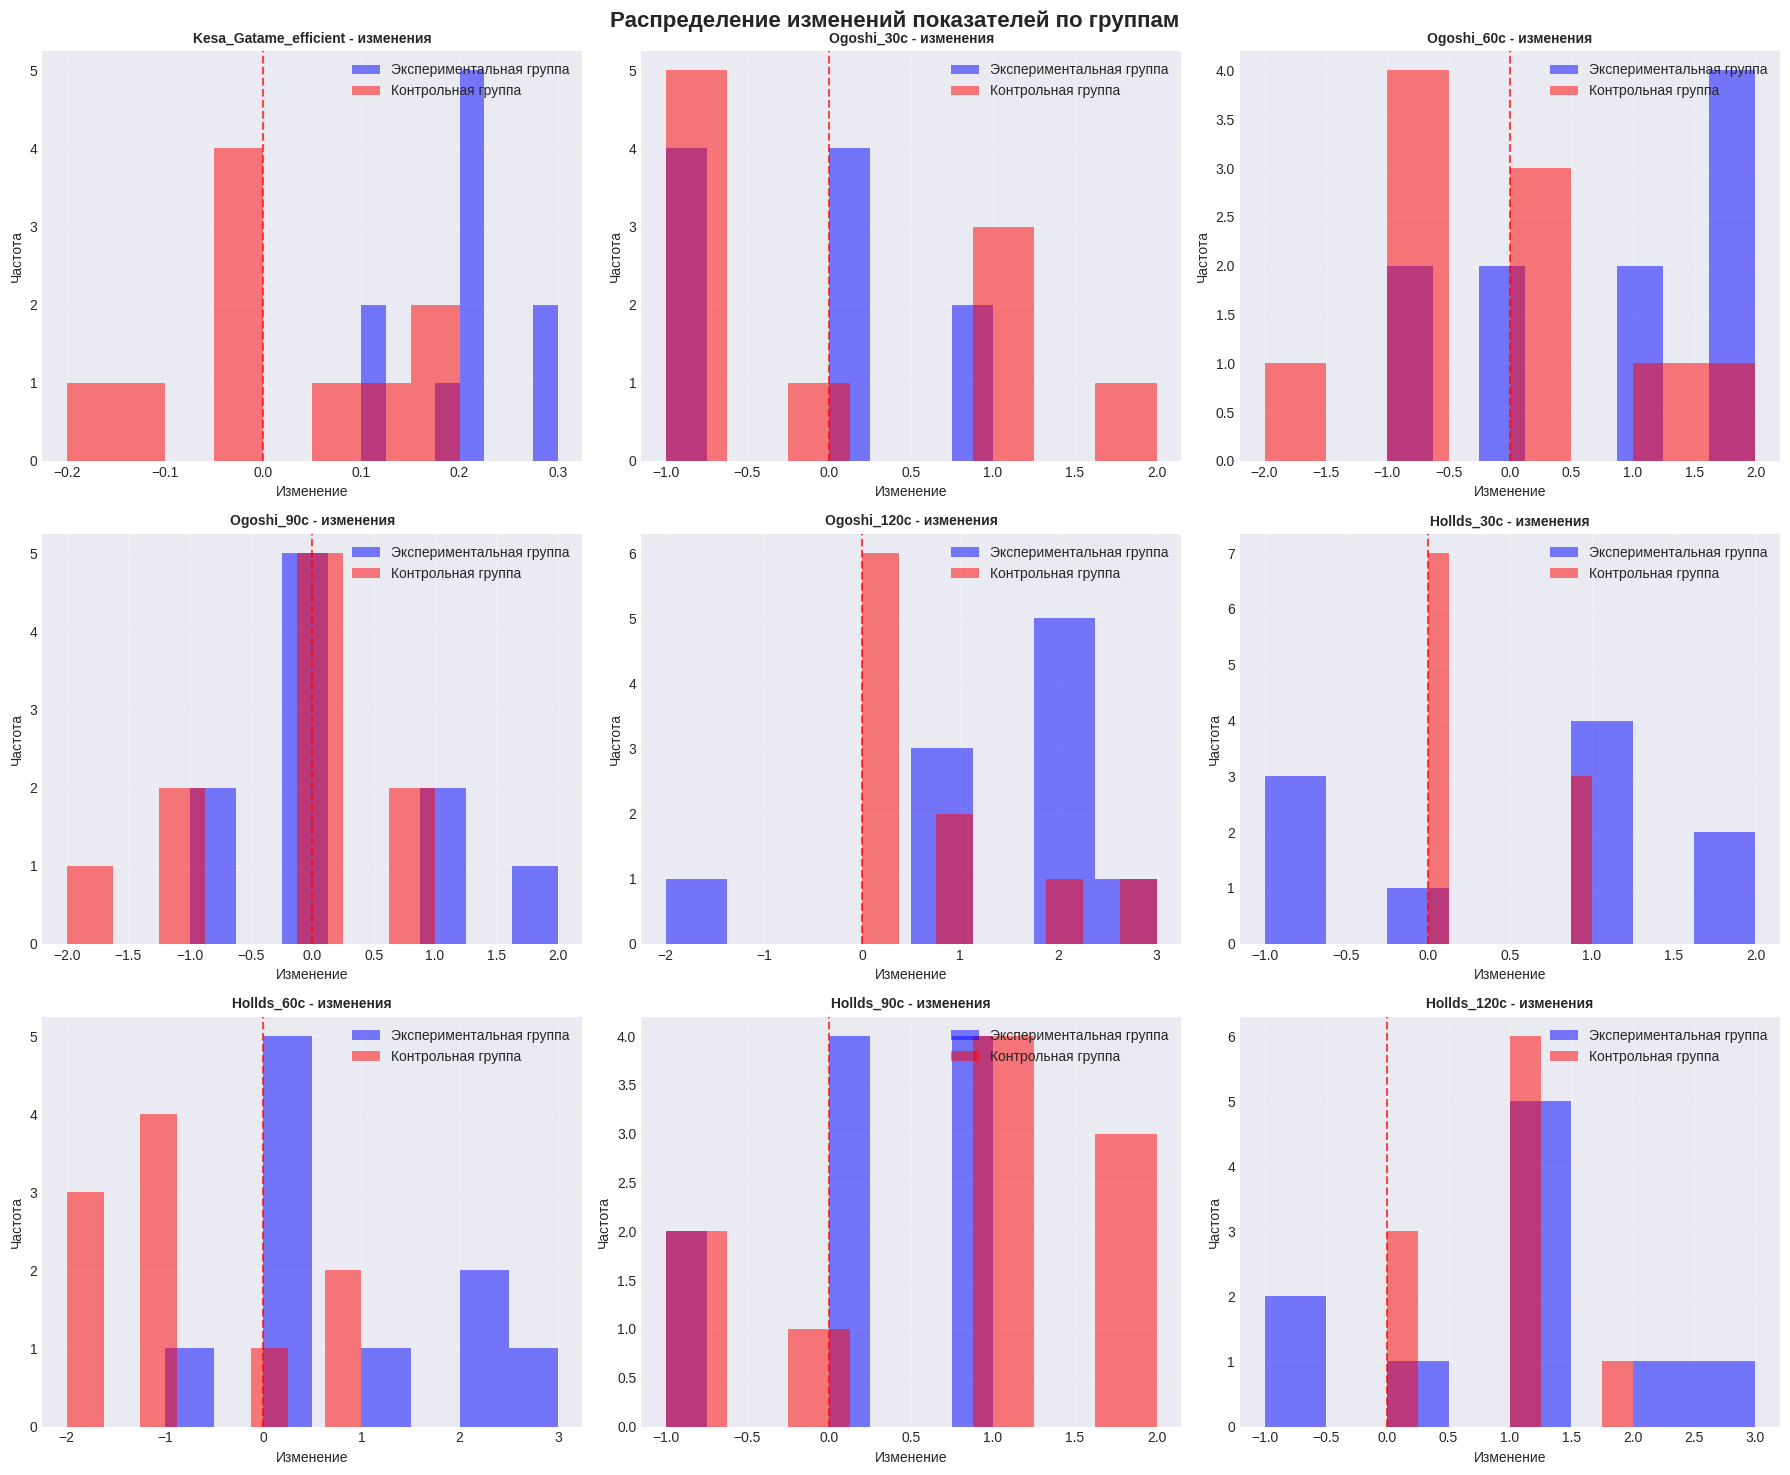

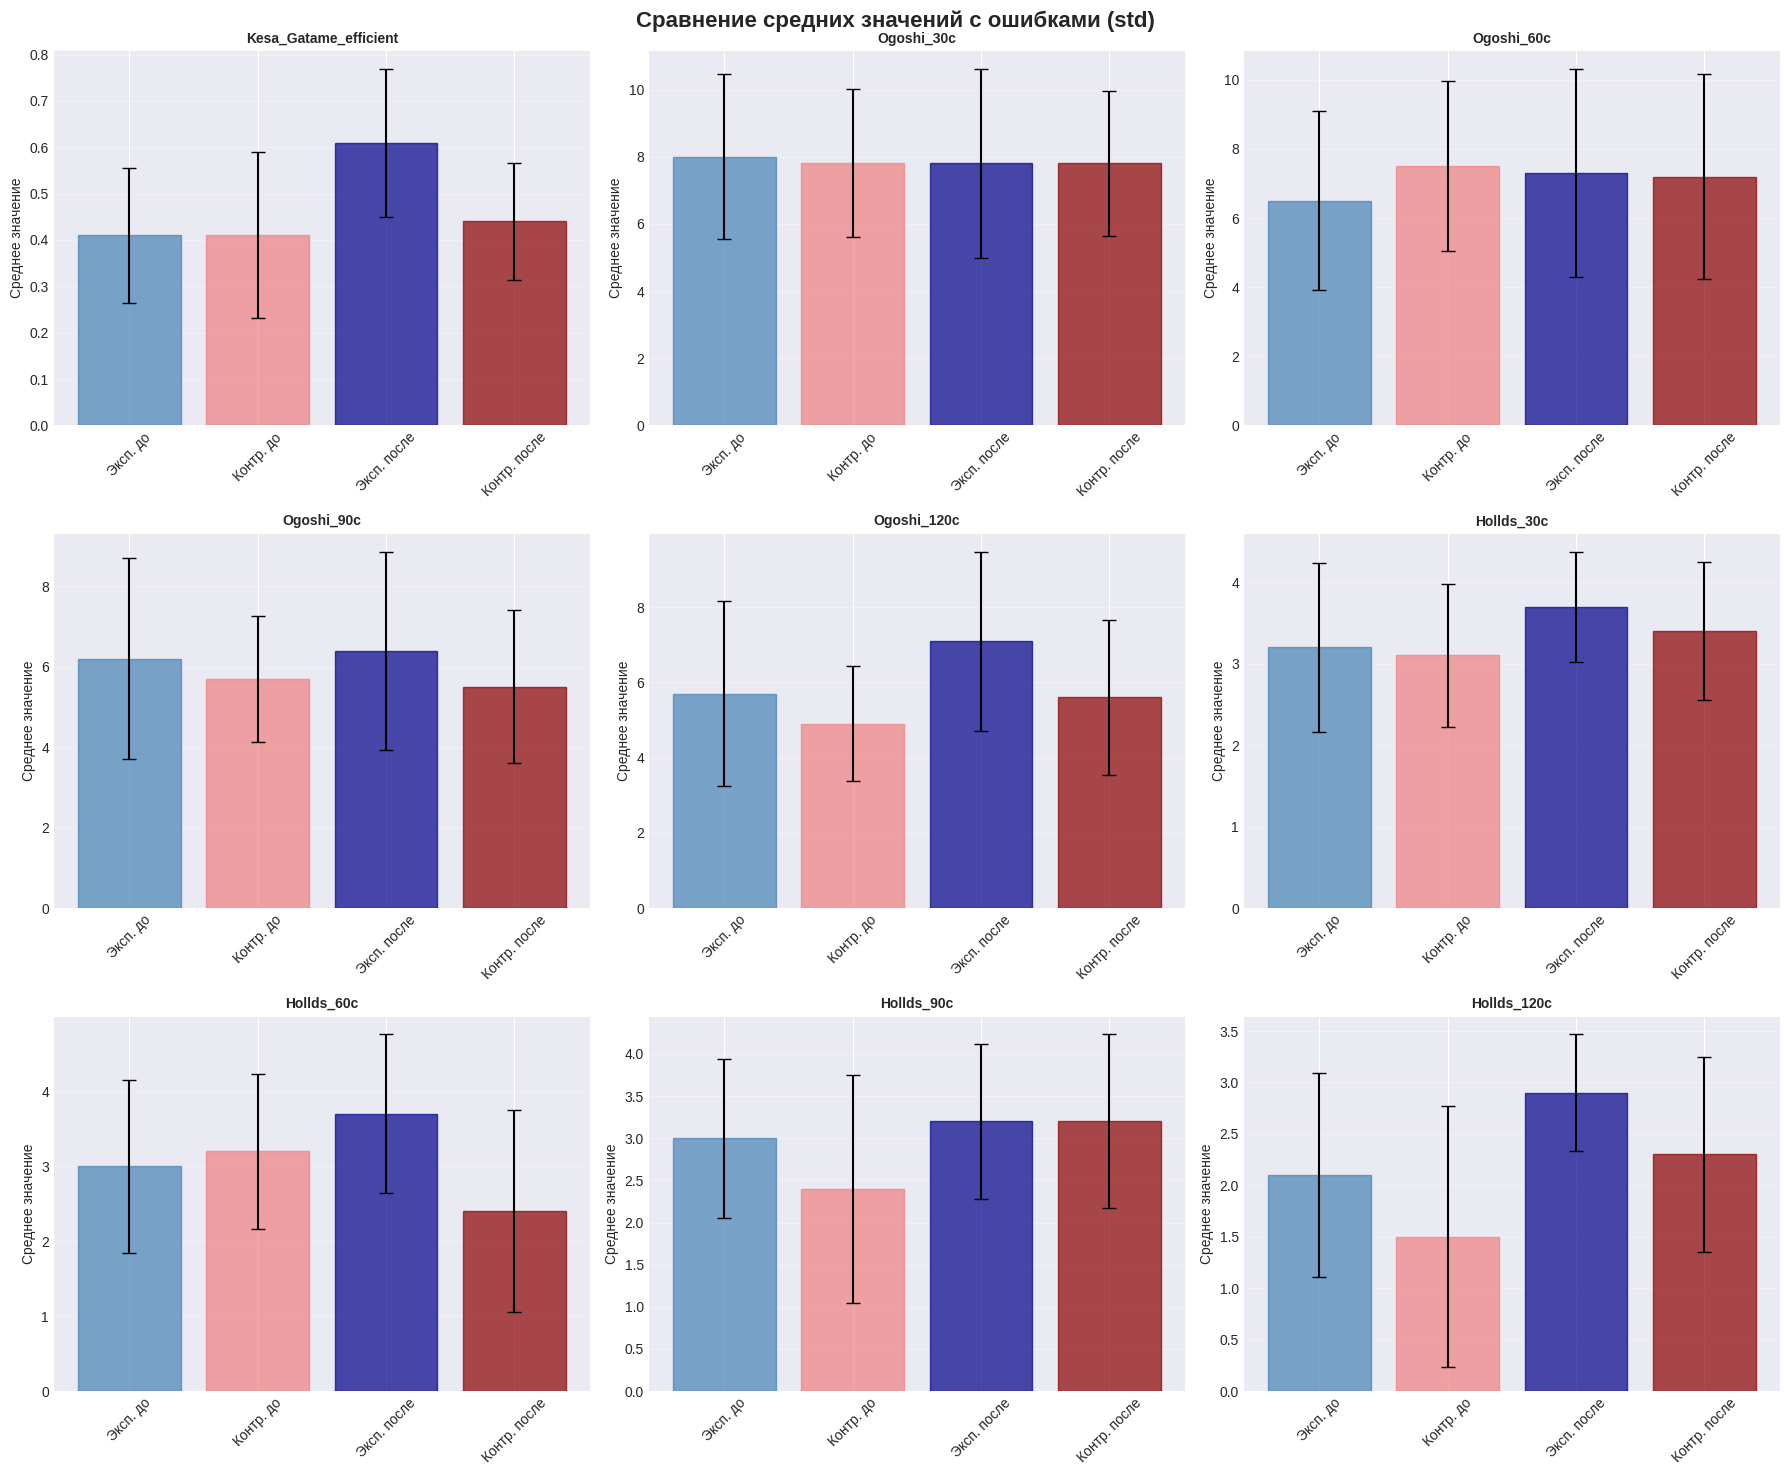


МАТЕМАТИЧЕСКАЯ МОДЕЛЬ ИЗМЕНЕНИЙ

Модель предсказания эффективности Kesa_Gatame после эксперимента:
R² = 1.0000
Коэффициенты: [ 1.74176776  0.16799538 -0.01062969 -0.3270364   0.11380705 -0.05141537
  0.03235124  0.16348931  0.05707683]
Интерсепт: -0.5429


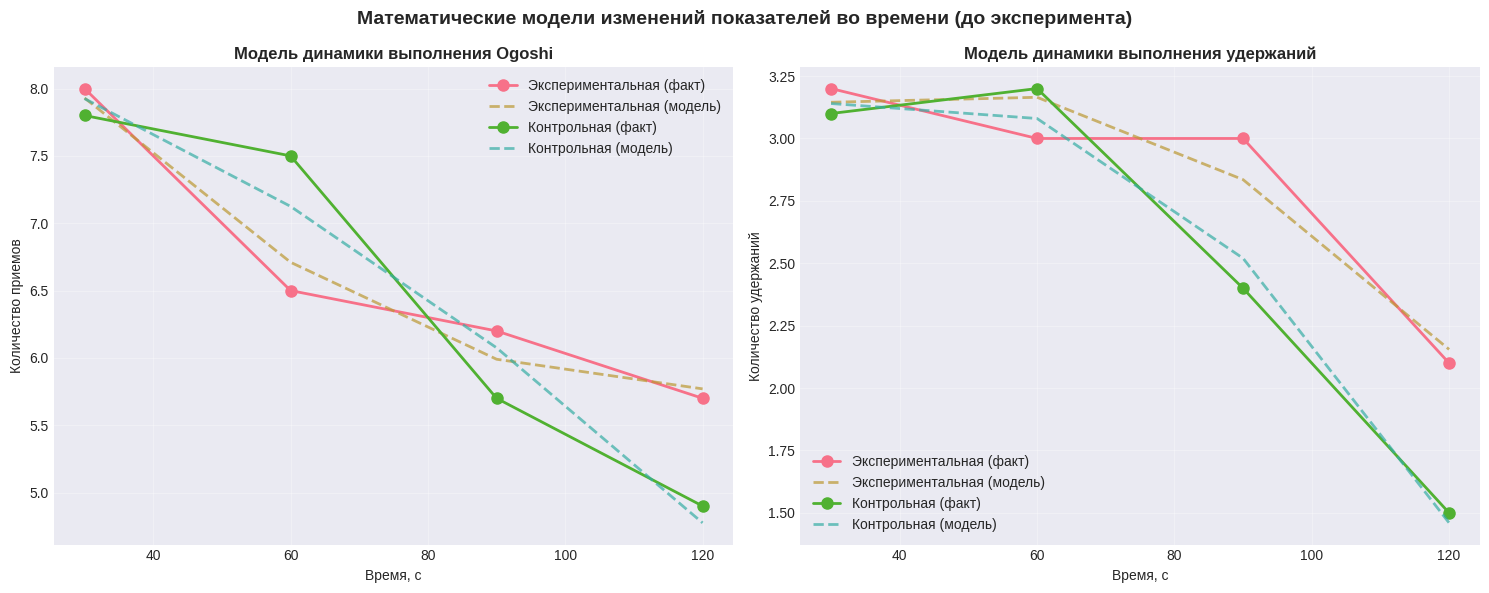


5 ИДЕЙ ДЛЯ ДАЛЬНЕЙШЕГО ИССЛЕДОВАНИЯ ДАННЫХ

1. АНАЛИЗ ВЫНОСЛИВОСТИ (скорость снижения эффективности)
   - Расчет коэффициента утомляемости
   - Сравнение темпов снижения производительности между группами


Коэффициенты утомляемости для Ogoshi (отрицательные значения указывают на снижение):

ДО ЭКСПЕРИМЕНТА:
Контрольная: -0.0350
Экспериментальная: -0.0240

ПОСЛЕ ЭКСПЕРИМЕНТА:
Контрольная: -0.0277
Экспериментальная: -0.0100

2. КЛАСТЕРНЫЙ АНАЛИЗ СПОРТСМЕНОВ
   - Группировка спортсменов по паттернам изменений
   - Выявление типов реагирования на тренировочную программу



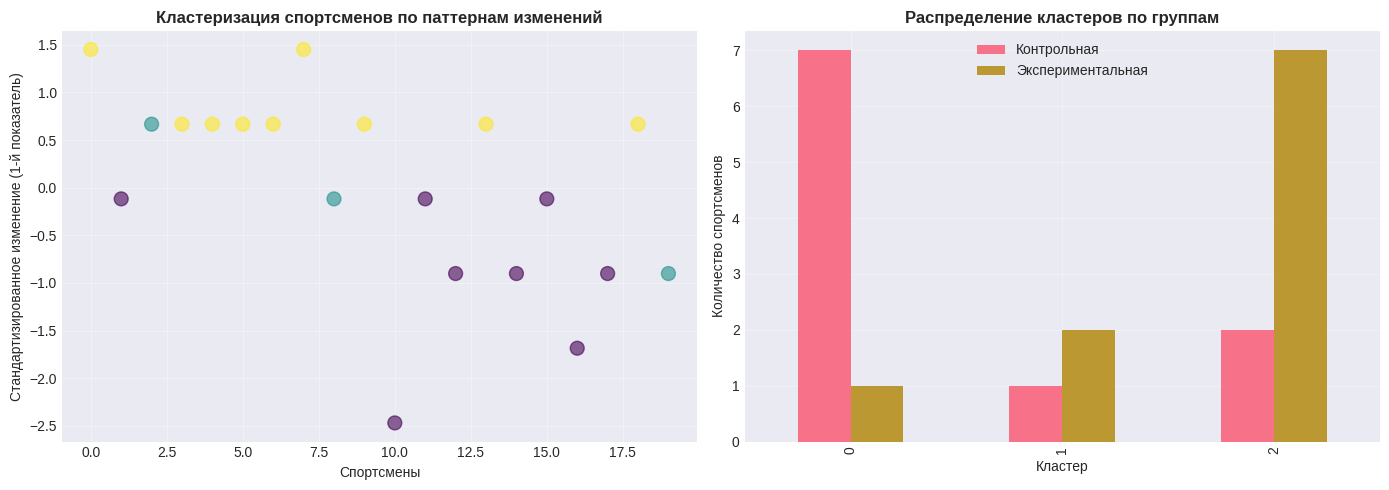


3. АНАЛИЗ ВЗАИМОСВЯЗИ ТЕХНИЧЕСКИХ ДЕЙСТВИЙ
   - Корреляционный анализ между различными приемами
   - Построение сетевой модели взаимовлияний



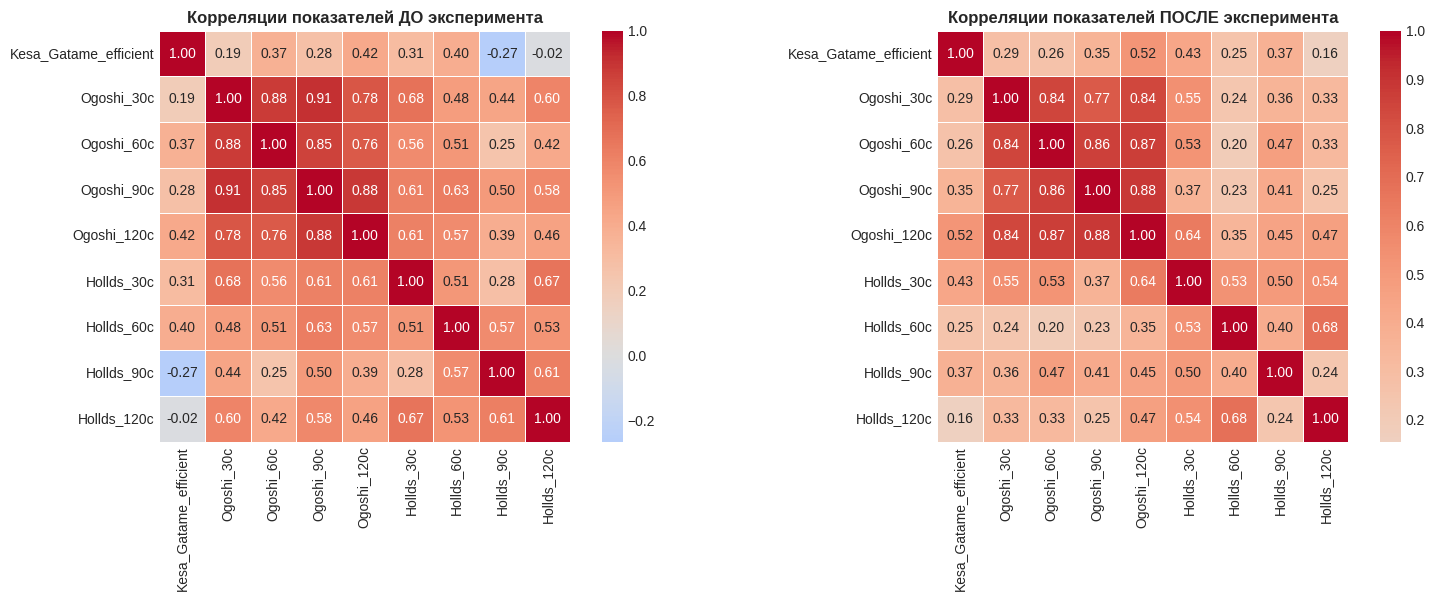


4. ПРОГНОЗИРОВАНИЕ ЭФФЕКТИВНОСТИ
   - Построение моделей машинного обучения для предсказания результатов
   - Определение ключевых факторов успеха


Важность показателей для прогнозирования эффективности Kesa_Gatame:
                 feature  importance
0  Kesa_Gatame_efficient    0.344592
2             Ogoshi_60с    0.144000
1             Ogoshi_30с    0.136855
4            Ogoshi_120с    0.100059
3             Ogoshi_90с    0.068731
8            Hollds_120с    0.067087
7             Hollds_90с    0.050185
5             Hollds_30с    0.048617
6             Hollds_60с    0.039874


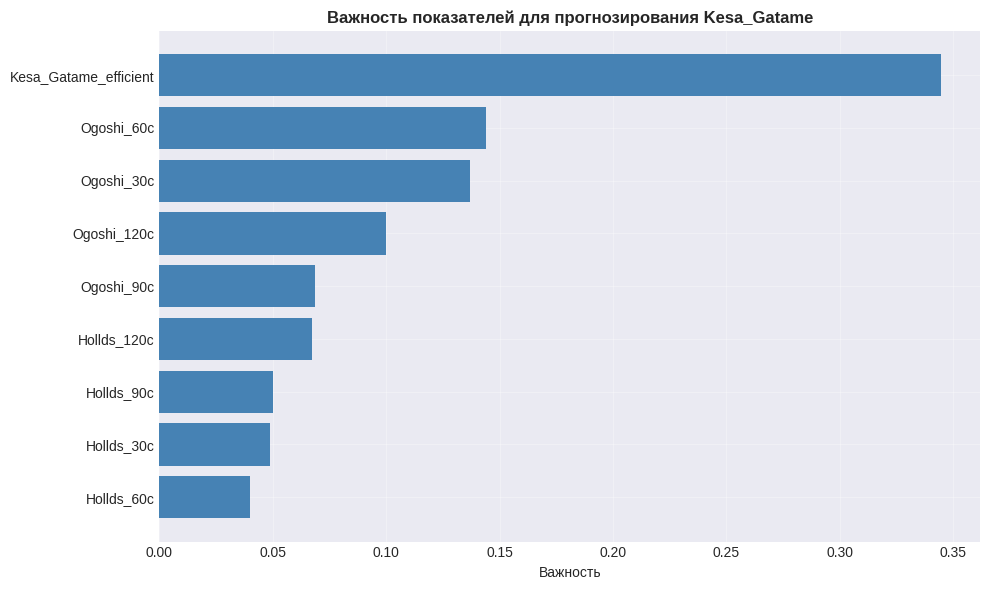


5. АНАЛИЗ ИНДИВИДУАЛЬНЫХ ТРАЕКТОРИЙ РАЗВИТИЯ
   - Персонализированный анализ прогресса каждого спортсмена
   - Выявление факторов, влияющих на индивидуальный прогресс



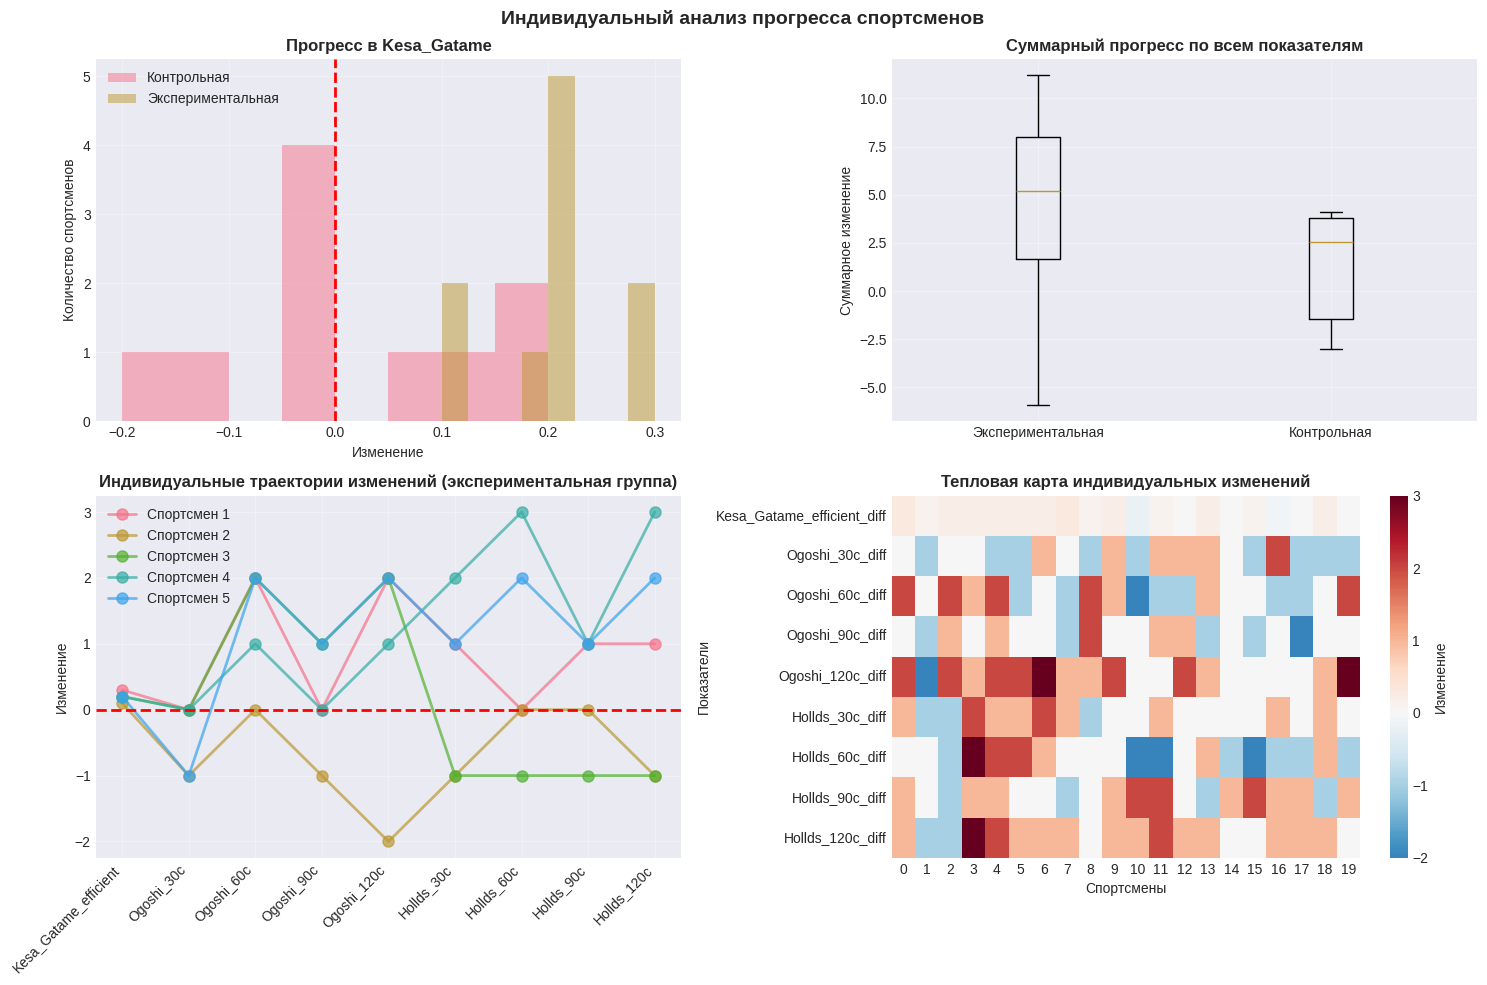


ИТОГОВЫЕ ВЫВОДЫ

Количество показателей со значимыми различиями в изменениях: 2

Значимые различия обнаружены для:
                variable   p_value
0  Kesa_Gatame_efficient  0.001339
6             Hollds_60с  0.011660

Средний суммарный прогресс:
Экспериментальная группа: 4.60
Контрольная группа: 1.33
Разница: 3.27

Эффективность эксперимента (разница в прогрессе): 3.27

ЗАВЕРШЕНО


In [3]:
#!pip install pingouin openpyxl plotly

# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, levene, mannwhitneyu, ttest_ind, f_oneway
import pingouin as pg
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Настройка стилей
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Загрузка данных
print("Загрузка данных...")
from google.colab import files
uploaded = files.upload()

# Чтение данных
file_name = list(uploaded.keys())[0]
df_before = pd.read_excel(file_name, sheet_name='before')
df_after = pd.read_excel(file_name, sheet_name='after')

# Просмотр названий столбцов для проверки
print("\nНазвания столбцов в данных до эксперимента:")
print(df_before.columns.tolist())
print("\nНазвания столбцов в данных после эксперимента:")
print(df_after.columns.tolist())

# Правильные названия столбцов (как в ваших данных)
variables = ['Kesa_Gatame_efficient', 'Ogoshi_30с', 'Ogoshi_60с',
             'Ogoshi_90с', 'Ogoshi_120с', 'Hollds_30с', 'Hollds_60с',
             'Hollds_90с', 'Hollds_120с']

print("\n" + "="*80)
print("ОПИСАТЕЛЬНАЯ СТАТИСТИКА")
print("="*80)

def descriptive_stats(df, period):
    print(f"\n{period}:")
    print(f"Экспериментальная группа (Groupe=1): n={len(df[df['Groupe']==1])}")
    print(f"Контрольная группа (Groupe=0): n={len(df[df['Groupe']==0])}")

    stats_df = df.groupby('Groupe')[variables].agg(['mean', 'std', 'min', 'max']).round(2)
    print(stats_df)

descriptive_stats(df_before, "ДО ЭКСПЕРИМЕНТА")
descriptive_stats(df_after, "ПОСЛЕ ЭКСПЕРИМЕНТА")

# 1. СТАТИСТИЧЕСКАЯ ПРОВЕРКА НОРМАЛЬНОСТИ
print("\n" + "="*80)
print("ПРОВЕРКА НОРМАЛЬНОСТИ РАСПРЕДЕЛЕНИЯ (тест Шапиро-Уилка)")
print("="*80)

def check_normality(df, variables, period):
    print(f"\n{period}:")
    for var in variables:
        stat, p_value = shapiro(df[var].dropna())
        normal = "нормальное" if p_value > 0.05 else "НЕ нормальное"
        print(f"{var}: p-value = {p_value:.4f} - {normal} распределение")

check_normality(df_before, variables, "ДО ЭКСПЕРИМЕНТА")
check_normality(df_after, variables, "ПОСЛЕ ЭКСПЕРИМЕНТА")

# 2. СРАВНЕНИЕ ГРУПП ДО ЭКСПЕРИМЕНТА
print("\n" + "="*80)
print("СРАВНЕНИЕ КОНТРОЛЬНОЙ И ЭКСПЕРИМЕНТАЛЬНОЙ ГРУПП ДО ЭКСПЕРИМЕНТА")
print("="*80)

def compare_groups(df, variables):
    results = []
    for var in variables:
        group1 = df[df['Groupe']==1][var].dropna()
        group0 = df[df['Groupe']==0][var].dropna()

        # Проверка равенства дисперсий
        stat_levene, p_levene = levene(group1, group0)

        # Выбор теста
        if p_levene > 0.05:
            stat, p_value = ttest_ind(group1, group0, equal_var=True)
            test_name = "t-test"
        else:
            stat, p_value = mannwhitneyu(group1, group0)
            test_name = "Mann-Whitney U"

        results.append({
            'variable': var,
            'test': test_name,
            'levene_p': p_levene,
            'p_value': p_value,
            'significant': 'Да' if p_value < 0.05 else 'Нет'
        })

    return pd.DataFrame(results)

comparison_before = compare_groups(df_before, variables)
print("\nДО ЭКСПЕРИМЕНТА:")
print(comparison_before.to_string())

# 3. СРАВНЕНИЕ ГРУПП ПОСЛЕ ЭКСПЕРИМЕНТА
comparison_after = compare_groups(df_after, variables)
print("\nПОСЛЕ ЭКСПЕРИМЕНТА:")
print(comparison_after.to_string())

# 4. АНАЛИЗ ИЗМЕНЕНИЙ (разница "после - до")
print("\n" + "="*80)
print("АНАЛИЗ ИЗМЕНЕНИЙ ПОКАЗАТЕЛЕЙ")
print("="*80)

# Создание датафреймов с разницей
df_diff = pd.DataFrame()
df_diff['Groupe'] = df_before['Groupe']

for var in variables:
    df_diff[f'{var}_diff'] = df_after[var] - df_before[var]

# Сравнение изменений между группами
diff_comparison = compare_groups(df_diff, [f'{var}_diff' for var in variables])
diff_comparison['variable'] = diff_comparison['variable'].str.replace('_diff', '')
print("\nСравнение изменений между группами:")
print(diff_comparison.to_string())

# 5. ВИЗУАЛИЗАЦИИ
print("\n" + "="*80)
print("СОЗДАНИЕ ВИЗУАЛИЗАЦИЙ")
print("="*80)

# 5.1 Boxplot сравнения групп до и после
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.ravel()

for idx, var in enumerate(variables):
    data_to_plot = []
    labels = []

    # Экспериментальная группа до
    exp_before = df_before[df_before['Groupe']==1][var].values
    # Контрольная группа до
    con_before = df_before[df_before['Groupe']==0][var].values
    # Экспериментальная группа после
    exp_after = df_after[df_after['Groupe']==1][var].values
    # Контрольная группа после
    con_after = df_after[df_after['Groupe']==0][var].values

    data_to_plot.extend([exp_before, con_before, exp_after, con_after])
    labels.extend(['Эксп. до', 'Контр. до', 'Эксп. после', 'Контр. после'])

    bp = axes[idx].boxplot(data_to_plot, labels=labels, patch_artist=True)
    bp['boxes'][0].set_facecolor('lightblue')
    bp['boxes'][1].set_facecolor('lightcoral')
    bp['boxes'][2].set_facecolor('steelblue')
    bp['boxes'][3].set_facecolor('indianred')

    axes[idx].set_title(f'{var}', fontsize=10, fontweight='bold')
    axes[idx].set_ylabel('Значение')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].tick_params(axis='x', rotation=45)

plt.suptitle('Сравнение показателей между группами до и после эксперимента',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# 5.2 Тепловая карта корреляций изменений
plt.figure(figsize=(12, 10))
diff_vars = [f'{var}_diff' for var in variables]
corr_matrix = df_diff[diff_vars].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5)
plt.title('Корреляционная матрица изменений показателей', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 5.3 График изменений для каждого показателя
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.ravel()

for idx, var in enumerate(variables):
    exp_changes = df_diff[df_diff['Groupe']==1][f'{var}_diff']
    con_changes = df_diff[df_diff['Groupe']==0][f'{var}_diff']

    axes[idx].hist(exp_changes, alpha=0.5, label='Экспериментальная группа', bins=8, color='blue')
    axes[idx].hist(con_changes, alpha=0.5, label='Контрольная группа', bins=8, color='red')
    axes[idx].axvline(x=0, color='red', linestyle='--', alpha=0.7)
    axes[idx].set_title(f'{var} - изменения', fontsize=10, fontweight='bold')
    axes[idx].set_xlabel('Изменение')
    axes[idx].set_ylabel('Частота')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Распределение изменений показателей по группам',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# 5.4 Столбчатая диаграмма средних значений
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.ravel()

for idx, var in enumerate(variables):
    means = [
        df_before[df_before['Groupe']==1][var].mean(),
        df_before[df_before['Groupe']==0][var].mean(),
        df_after[df_after['Groupe']==1][var].mean(),
        df_after[df_after['Groupe']==0][var].mean()
    ]
    stds = [
        df_before[df_before['Groupe']==1][var].std(),
        df_before[df_before['Groupe']==0][var].std(),
        df_after[df_after['Groupe']==1][var].std(),
        df_after[df_after['Groupe']==0][var].std()
    ]

    x_pos = np.arange(4)
    bars = axes[idx].bar(x_pos, means, yerr=stds, capsize=5, alpha=0.7)
    bars[0].set_color('steelblue')
    bars[1].set_color('lightcoral')
    bars[2].set_color('darkblue')
    bars[3].set_color('darkred')

    axes[idx].set_xticks(x_pos)
    axes[idx].set_xticklabels(['Эксп. до', 'Контр. до', 'Эксп. после', 'Контр. после'], rotation=45)
    axes[idx].set_title(f'{var}', fontsize=10, fontweight='bold')
    axes[idx].set_ylabel('Среднее значение')
    axes[idx].grid(True, alpha=0.3, axis='y')

plt.suptitle('Сравнение средних значений с ошибками (std)',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# 6. МАТЕМАТИЧЕСКАЯ МОДЕЛЬ ИЗМЕНЕНИЙ
print("\n" + "="*80)
print("МАТЕМАТИЧЕСКАЯ МОДЕЛЬ ИЗМЕНЕНИЙ")
print("="*80)

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

# Создание модели для экспериментальной группы
exp_before = df_before[df_before['Groupe']==1]
exp_after = df_after[df_after['Groupe']==1]

# Модель множественной линейной регрессии
X = exp_before[variables].values
y = exp_after['Kesa_Gatame_efficient'].values

model = LinearRegression()
model.fit(X, y)

print("\nМодель предсказания эффективности Kesa_Gatame после эксперимента:")
print(f"R² = {model.score(X, y):.4f}")
print(f"Коэффициенты: {model.coef_}")
print(f"Интерсепт: {model.intercept_:.4f}")

# Создание модели изменений во времени
time_points = [30, 60, 90, 120]
time_series_ogoshi = []
time_series_holds = []

for group_name, group_data in [('Экспериментальная', exp_before),
                                ('Контрольная', df_before[df_before['Groupe']==0])]:
    ogoshi_means = [group_data[f'Ogoshi_{t}с'].mean() for t in time_points]
    holds_means = [group_data[f'Hollds_{t}с'].mean() for t in time_points]
    time_series_ogoshi.append(ogoshi_means)
    time_series_holds.append(holds_means)

# Полиномиальная регрессия для моделирования утомления
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(np.array(time_points).reshape(-1, 1))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for idx, (ogoshi_data, holds_data, label) in enumerate(zip(time_series_ogoshi, time_series_holds,
                                                           ['Экспериментальная', 'Контрольная'])):
    # Модель для Ogoshi
    model_ogoshi = LinearRegression()
    model_ogoshi.fit(X_poly, ogoshi_data)
    y_pred_ogoshi = model_ogoshi.predict(X_poly)

    # Модель для Hollds
    model_holds = LinearRegression()
    model_holds.fit(X_poly, holds_data)
    y_pred_holds = model_holds.predict(X_poly)

    axes[0].plot(time_points, ogoshi_data, 'o-', label=f'{label} (факт)', linewidth=2, markersize=8)
    axes[0].plot(time_points, y_pred_ogoshi, '--', label=f'{label} (модель)', alpha=0.7, linewidth=2)
    axes[1].plot(time_points, holds_data, 'o-', label=f'{label} (факт)', linewidth=2, markersize=8)
    axes[1].plot(time_points, y_pred_holds, '--', label=f'{label} (модель)', alpha=0.7, linewidth=2)

axes[0].set_title('Модель динамики выполнения Ogoshi', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Время, с')
axes[0].set_ylabel('Количество приемов')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Модель динамики выполнения удержаний', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Время, с')
axes[1].set_ylabel('Количество удержаний')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Математические модели изменений показателей во времени (до эксперимента)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 7. ПЯТЬ ИДЕЙ ДЛЯ ДАЛЬНЕЙШЕГО ИССЛЕДОВАНИЯ
print("\n" + "="*80)
print("5 ИДЕЙ ДЛЯ ДАЛЬНЕЙШЕГО ИССЛЕДОВАНИЯ ДАННЫХ")
print("="*80)

print("""
1. АНАЛИЗ ВЫНОСЛИВОСТИ (скорость снижения эффективности)
   - Расчет коэффициента утомляемости
   - Сравнение темпов снижения производительности между группами
""")

# Пример реализации идеи 1
fatigue_rate_ogoshi_before = {}
fatigue_rate_ogoshi_after = {}

for group in [0, 1]:
    group_name = 'Экспериментальная' if group == 1 else 'Контрольная'

    # До эксперимента
    group_data_before = df_before[df_before['Groupe']==group]
    ogoshi_series_before = [group_data_before[f'Ogoshi_{t}с'].mean() for t in time_points]
    slope_before, intercept_before = np.polyfit(time_points, ogoshi_series_before, 1)
    fatigue_rate_ogoshi_before[group_name] = slope_before

    # После эксперимента
    group_data_after = df_after[df_after['Groupe']==group]
    ogoshi_series_after = [group_data_after[f'Ogoshi_{t}с'].mean() for t in time_points]
    slope_after, intercept_after = np.polyfit(time_points, ogoshi_series_after, 1)
    fatigue_rate_ogoshi_after[group_name] = slope_after

print("\nКоэффициенты утомляемости для Ogoshi (отрицательные значения указывают на снижение):")
print("\nДО ЭКСПЕРИМЕНТА:")
for group, rate in fatigue_rate_ogoshi_before.items():
    print(f"{group}: {rate:.4f}")
print("\nПОСЛЕ ЭКСПЕРИМЕНТА:")
for group, rate in fatigue_rate_ogoshi_after.items():
    print(f"{group}: {rate:.4f}")

print("""
2. КЛАСТЕРНЫЙ АНАЛИЗ СПОРТСМЕНОВ
   - Группировка спортсменов по паттернам изменений
   - Выявление типов реагирования на тренировочную программу
""")

# Пример реализации идеи 2
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Подготовка данных для кластеризации (изменения показателей)
scaler = StandardScaler()
features_for_clustering = [f'{var}_diff' for var in variables]
X_cluster = scaler.fit_transform(df_diff[features_for_clustering])

# Кластеризация
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_cluster)

# Визуализация кластеров
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График распределения кластеров
axes[0].scatter(range(len(clusters)), X_cluster[:, 0], c=clusters, cmap='viridis', alpha=0.6, s=100)
axes[0].set_title('Кластеризация спортсменов по паттернам изменений', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Спортсмены')
axes[0].set_ylabel('Стандартизированное изменение (1-й показатель)')
axes[0].grid(True, alpha=0.3)

# Распределение кластеров по группам
cluster_df = pd.DataFrame({'cluster': clusters, 'group': df_diff['Groupe']})
cluster_counts = pd.crosstab(cluster_df['cluster'], cluster_df['group'])
cluster_counts.columns = ['Контрольная', 'Экспериментальная']
cluster_counts.plot(kind='bar', ax=axes[1])
axes[1].set_title('Распределение кластеров по группам', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Кластер')
axes[1].set_ylabel('Количество спортсменов')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("""
3. АНАЛИЗ ВЗАИМОСВЯЗИ ТЕХНИЧЕСКИХ ДЕЙСТВИЙ
   - Корреляционный анализ между различными приемами
   - Построение сетевой модели взаимовлияний
""")

# Пример реализации идеи 3
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Корреляционная матрица до эксперимента
corr_before = df_before[variables].corr()
sns.heatmap(corr_before, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=axes[0])
axes[0].set_title('Корреляции показателей ДО эксперимента', fontsize=12, fontweight='bold')

# Корреляционная матрица после эксперимента
corr_after = df_after[variables].corr()
sns.heatmap(corr_after, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=axes[1])
axes[1].set_title('Корреляции показателей ПОСЛЕ эксперимента', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("""
4. ПРОГНОЗИРОВАНИЕ ЭФФЕКТИВНОСТИ
   - Построение моделей машинного обучения для предсказания результатов
   - Определение ключевых факторов успеха
""")

# Пример реализации идеи 4
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Подготовка данных
X = df_before[variables].values
y = df_after['Kesa_Gatame_efficient'].values

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Обучение модели Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Оценка важности признаков
feature_importance = pd.DataFrame({
    'feature': variables,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nВажность показателей для прогнозирования эффективности Kesa_Gatame:")
print(feature_importance)

# Визуализация важности признаков
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'], color='steelblue')
plt.xlabel('Важность')
plt.title('Важность показателей для прогнозирования Kesa_Gatame', fontsize=12, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("""
5. АНАЛИЗ ИНДИВИДУАЛЬНЫХ ТРАЕКТОРИЙ РАЗВИТИЯ
   - Персонализированный анализ прогресса каждого спортсмена
   - Выявление факторов, влияющих на индивидуальный прогресс
""")

# Пример реализации идеи 5
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Прогресс по Kesa_Gatame
for group in [0, 1]:
    group_mask = df_before['Groupe'] == group
    progress = df_after[group_mask]['Kesa_Gatame_efficient'].values - df_before[group_mask]['Kesa_Gatame_efficient'].values
    axes[0, 0].hist(progress, alpha=0.5, label=f"{'Экспериментальная' if group==1 else 'Контрольная'}", bins=8)
axes[0, 0].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0, 0].set_title('Прогресс в Kesa_Gatame', fontweight='bold')
axes[0, 0].set_xlabel('Изменение')
axes[0, 0].set_ylabel('Количество спортсменов')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Суммарный прогресс по всем показателям
total_progress_exp = df_diff[df_diff['Groupe']==1][[f'{var}_diff' for var in variables]].sum(axis=1)
total_progress_con = df_diff[df_diff['Groupe']==0][[f'{var}_diff' for var in variables]].sum(axis=1)

axes[0, 1].boxplot([total_progress_exp, total_progress_con],
                   labels=['Экспериментальная', 'Контрольная'])
axes[0, 1].set_title('Суммарный прогресс по всем показателям', fontweight='bold')
axes[0, 1].set_ylabel('Суммарное изменение')
axes[0, 1].grid(True, alpha=0.3)

# Индивидуальные траектории (первые 5 спортсменов из экспериментальной группы)
exp_indices = df_diff[df_diff['Groupe']==1].index[:5]
for i, idx in enumerate(exp_indices):
    exp_changes = df_diff.iloc[idx][[f'{var}_diff' for var in variables]].values
    axes[1, 0].plot(range(len(variables)), exp_changes, 'o-', alpha=0.7, label=f'Спортсмен {i+1}', linewidth=2, markersize=8)
axes[1, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1, 0].set_title('Индивидуальные траектории изменений (экспериментальная группа)', fontweight='bold')
axes[1, 0].set_xticks(range(len(variables)))
axes[1, 0].set_xticklabels([v.replace('_diff', '') for v in [f'{var}_diff' for var in variables]], rotation=45, ha='right')
axes[1, 0].set_ylabel('Изменение')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Тепловая карта индивидуальных изменений
individual_changes = df_diff[[f'{var}_diff' for var in variables]].T
sns.heatmap(individual_changes, cmap='RdBu_r', center=0, ax=axes[1, 1],
            cbar_kws={'label': 'Изменение'})
axes[1, 1].set_title('Тепловая карта индивидуальных изменений', fontweight='bold')
axes[1, 1].set_xlabel('Спортсмены')
axes[1, 1].set_ylabel('Показатели')

plt.suptitle('Индивидуальный анализ прогресса спортсменов', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Финальная статистика
print("\n" + "="*80)
print("ИТОГОВЫЕ ВЫВОДЫ")
print("="*80)

# Подсчет значимых различий
significant_changes = diff_comparison[diff_comparison['significant'] == 'Да']
print(f"\nКоличество показателей со значимыми различиями в изменениях: {len(significant_changes)}")
if len(significant_changes) > 0:
    print("\nЗначимые различия обнаружены для:")
    print(significant_changes[['variable', 'p_value']].to_string())

# Средний прогресс по группам
mean_progress_exp = total_progress_exp.mean()
mean_progress_con = total_progress_con.mean()
print(f"\nСредний суммарный прогресс:")
print(f"Экспериментальная группа: {mean_progress_exp:.2f}")
print(f"Контрольная группа: {mean_progress_con:.2f}")
print(f"Разница: {mean_progress_exp - mean_progress_con:.2f}")

# Эффективность эксперимента
print(f"\nЭффективность эксперимента (разница в прогрессе): {mean_progress_exp - mean_progress_con:.2f}")

print("\n" + "="*80)
print("ЗАВЕРШЕНО")
print("="*80)